# 01_EDA_Olist_Dataset

Notebook này bao phủ phần mô tả dữ liệu, khảo sát dữ liệu ban đầu và EDA sâu theo hướng file-by-file, có visualize sau khi đã aggregate bằng PySpark.


# ROADMAP TOÀN BỘ COMMAND

Notebook 01 đi từ khởi tạo môi trường -> đọc từng file CSV -> profiling -> audit chất lượng -> EDA theo chủ đề nghiệp vụ.


## 4.1. Mô tả bộ dữ liệu Olist

Phần này mô tả từng file CSV, phạm vi dữ liệu và quan hệ giữa các bảng trước khi đi sâu vào khảo sát và EDA.


[COMMAND_SO]
Command 1

[COMMAND_MUC_DICH]
- Mục tiêu nghiệp vụ: Khởi tạo môi trường ổn định cho toàn bộ notebook EDA.
- Mục tiêu kỹ thuật: Tạo SparkSession, ép cùng Python runtime và chuẩn bị helper load/profile/visualize.
- Command này là nền cho toàn bộ các command sau.


**[C1-1] Import thư viện**

- Thư viện chuẩn: `pathlib`, `os`, `sys`, `warnings`.
- `pandas` + `matplotlib`: xử lý dữ liệu nhỏ và vẽ biểu đồ.
- PySpark: `SparkSession`, `DataFrame`, `functions as F`, kiểu dữ liệu (`TimestampType`, `StringType`…).


In [1]:
# Command 1 - Khởi tạo môi trường và helper dùng chung
from pathlib import Path
import os
import json
import sys
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession, DataFrame
from pyspark.sql import functions as F
from pyspark.sql.types import (
    DateType,
    DecimalType,
    DoubleType,
    FloatType,
    IntegerType,
    LongType,
    StringType,
    TimestampType,
)
from pyspark.sql.window import Window


**[C1-2] Cấu hình môi trường & khởi tạo SparkSession**

- Tắt warning không liên quan; thiết lập hiển thị pandas và style biểu đồ.
- Đồng bộ Python interpreter giữa driver và worker (`PYSPARK_PYTHON`) để tránh version mismatch.
- Dừng session cũ nếu tồn tại (`getActiveSession().stop()`) trước khi tạo mới.
- **SparkSession config**: `local[*]` (dùng tất cả core), 4GB RAM, 8 shuffle partitions, UTC timezone.


In [2]:

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
plt.style.use("seaborn-v0_8-whitegrid")

# Đồng bộ Python giữa driver và worker để tránh PYTHON_VERSION_MISMATCH
python_exec = sys.executable
os.environ["PYSPARK_PYTHON"] = python_exec
os.environ["PYSPARK_DRIVER_PYTHON"] = python_exec

active_spark = SparkSession.getActiveSession()
if active_spark is not None:
    active_spark.stop()

spark = (
    SparkSession.builder
    .appName("Nhom03_Olist_EDA") # type: ignore
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.sql.session.timeZone", "UTC")
    .config("spark.pyspark.python", python_exec)
    .config("spark.pyspark.driver.python", python_exec)
    .config("spark.executorEnv.PYSPARK_PYTHON", python_exec)
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")


26/03/31 22:12:30 WARN Utils: Your hostname, Genius-Macbook.local resolves to a loopback address: 127.0.0.1; using 192.168.2.18 instead (on interface en0)
26/03/31 22:12:30 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/31 22:12:30 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/03/31 22:12:31 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


**[C1-3] Thiết lập đường dẫn & khai báo bảng dữ liệu**

- `PROJECT_ROOT`: tự detect gốc dự án (kiểm tra xem đang chạy trong `notebooks/` hay không).
- `DATA_DIR` = `data/raw/`, `PROCESSED_DIR` = `data/processed/` — tách biệt input và output.
- `TABLE_FILES`: dict ánh xạ tên logic → tên file CSV thực tế — dễ thay đổi đường dẫn mà không sửa code phân tích.
- `DATETIME_PATTERNS`: tuple các pattern tên cột để nhận diện cột datetime trong helper functions.


In [3]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

TABLE_FILES = {
    "customers": "olist_customers_dataset.csv",
    "orders": "olist_orders_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "order_payments": "olist_order_payments_dataset.csv",
    "order_reviews": "olist_order_reviews_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "geolocation": "olist_geolocation_dataset.csv",
    "category_translation": "product_category_name_translation.csv",
    "full_dataset": "olist_full_dataset.csv",
}



**[C1-4] Helper functions phân loại cột & null profile**

| Hàm | Mục đích |
|-----|----------|
| `classify_columns(df)` | Phân cột thành 4 nhóm: `datetime`, `numeric`, `categorical`, `text` dựa trên kiểu dữ liệu và tên cột |
| `build_null_profile(df)` | Đếm và tính tỉ lệ null cho từng cột, trả về DataFrame có thể `.show()` |

**Logic phân loại** trong `classify_columns`:
- `TimestampType/DateType` hoặc tên chứa `timestamp/_date/_at` → **datetime**.
- `IntegerType/LongType/DoubleType/FloatType/DecimalType` → **numeric**.
- `StringType` với `comment`/`description` trong tên → **text**; còn lại → **categorical**.


In [4]:
DATETIME_PATTERNS = ("timestamp", "_date", "_at")


def classify_columns(df: DataFrame) -> dict:
    datetime_cols, numeric_cols, categorical_cols, text_cols = [], [], [], []
    for field in df.schema.fields:
        col_name = field.name
        lower_name = col_name.lower()
        data_type = field.dataType

        if isinstance(data_type, (TimestampType, DateType)) or any(p in lower_name for p in DATETIME_PATTERNS):
            datetime_cols.append(col_name)
        elif isinstance(data_type, (IntegerType, LongType, DoubleType, FloatType, DecimalType)):
            numeric_cols.append(col_name)
        elif isinstance(data_type, StringType):
            if "comment" in lower_name or "description" in lower_name:
                text_cols.append(col_name)
            else:
                categorical_cols.append(col_name)

    return {
        "datetime_cols": datetime_cols,
        "numeric_cols": numeric_cols,
        "categorical_cols": categorical_cols,
        "text_cols": text_cols,
    }


def build_null_profile(df: DataFrame) -> DataFrame:
    total_rows = df.count()
    exprs = [F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c) for c in df.columns]
    null_counts = df.agg(*exprs)
    stacked_expr = "stack({0}, {1}) as (column_name, null_count)".format(
        len(df.columns),
        ", ".join([f"'{c}', `{c}`" for c in df.columns]),
    )
    return (
        null_counts
        .selectExpr(stacked_expr)
        .withColumn("row_count", F.lit(total_rows))
        .withColumn("null_ratio", F.when(F.col("row_count") > 0, F.col("null_count") / F.col("row_count")).otherwise(F.lit(0.0)))
        .orderBy(F.desc("null_ratio"), F.desc("null_count"))
    )



**[C1-5] Helper functions load & inspect từng bảng**

| Hàm | Mục đích |
|-----|----------|
| `load_single_table(table_name)` | Đọc CSV với `header=True, inferSchema=True`; in path xác nhận |
| `inspect_single_table(df, name)` | In row count, column count, schema, phân loại cột, sample rows và null profile |

Hai hàm này được gọi riêng cho từng file CSV ở **các cell tiếp theo** thay vì đọc tất cả một lúc.
Cách này giúp dễ debug khi một file có schema bất thường mà không ảnh hưởng các file khác.


In [5]:

def load_single_table(table_name: str) -> DataFrame:
    file_path = DATA_DIR / TABLE_FILES[table_name]
    df = (
        spark.read
        .option("header", True)
        .option("inferSchema", True)
        .csv(str(file_path))
    )
    print(f"Loaded table: {table_name} | path={file_path}")
    return df


def inspect_single_table(df: DataFrame, table_name: str, sample_rows: int = 5) -> None:
    print("=" * 100)
    print(f"TABLE: {table_name}")
    print(f"ROW COUNT: {df.count():,} | COLUMN COUNT: {len(df.columns)}")
    df.printSchema()

    groups = classify_columns(df)
    print(f"datetime_cols: {groups['datetime_cols']}")
    print(f"numeric_cols: {groups['numeric_cols']}")
    print(f"categorical_cols: {groups['categorical_cols']}")
    print(f"text_cols: {groups['text_cols']}")

    print("Sample rows:")
    df.show(sample_rows, truncate=False)

    print("Null profile:")
    build_null_profile(df).show(len(df.columns), truncate=False)



**[C1-6] Helper functions chuyển đổi & vẽ biểu đồ**

| Hàm | Mục đích |
|-----|----------|
| `to_pandas_small(df, limit)` | Lấy tối đa `limit` dòng về pandas để vẽ biểu đồ — tránh OOM |
| `plot_bar_from_spark(df, x, y, ...)` | Vẽ bar chart từ Spark DataFrame (hỗ trợ horizontal/vertical) |
| `plot_line_from_spark(df, x, y_cols, ...)` | Vẽ line chart nhiều series từ Spark DataFrame |

Cuối cell in xác nhận Spark version, Python path, DATA_DIR và số bảng kỳ vọng.


In [6]:

def to_pandas_small(df: DataFrame, limit: int = 1000) -> pd.DataFrame:
    limited_df = df.limit(limit)
    try:
        return limited_df.toPandas()
    except Exception as ex:
        print(f"Fallback chart collect due to: {type(ex).__name__}")
        try:
            json_rows = list(limited_df._jdf.toJSON().collect())
            return pd.DataFrame([json.loads(r) for r in json_rows]) if json_rows else pd.DataFrame()
        except Exception as inner_ex:
            print(f"Chart data collect failed: {type(inner_ex).__name__}")
            return pd.DataFrame()


def _to_sql_literal(value) -> str:
    if value is None:
        return "NULL"
    if isinstance(value, bool):
        return "TRUE" if value else "FALSE"
    if isinstance(value, (int, float, np.integer, np.floating)):
        if pd.isna(value) or np.isinf(value):
            return "NULL"
        return str(value)
    text = str(value).replace("'", "''")
    return f"'{text}'"


def create_spark_df_from_rows(rows: list[tuple], columns: list[str]) -> DataFrame:
    if not rows:
        empty_select = ", ".join([f"CAST(NULL AS STRING) AS `{c}`" for c in columns])
        return spark.sql(f"SELECT {empty_select} WHERE 1 = 0")

    values_sql = ", ".join(
        "(" + ", ".join(_to_sql_literal(v) for v in row) + ")"
        for row in rows
    )
    columns_sql = ", ".join([f"`{c}`" for c in columns])
    return spark.sql(f"SELECT * FROM VALUES {values_sql} AS t({columns_sql})")


def plot_bar_from_spark(df: DataFrame, x_col: str, y_col: str, title: str, xlabel: str, ylabel: str, limit: int = 20, horizontal: bool = False) -> None:
    pdf = to_pandas_small(df, limit)
    if pdf.empty:
        print(f"No data available for chart: {title}")
        return

    plt.figure(figsize=(12, 5))
    if horizontal:
        plt.barh(pdf[x_col].astype(str), pdf[y_col])
        plt.gca().invert_yaxis()
    else:
        plt.bar(pdf[x_col].astype(str), pdf[y_col])
        plt.xticks(rotation=45, ha="right")

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()


def plot_line_from_spark(df: DataFrame, x_col: str, y_cols: list[str], title: str, xlabel: str, ylabel: str, limit: int = 200) -> None:
    pdf = to_pandas_small(df, limit)
    if pdf.empty:
        print(f"No data available for chart: {title}")
        return

    plt.figure(figsize=(12, 5))
    for y_col in y_cols:
        plt.plot(pdf[x_col].astype(str), pdf[y_col], marker="o", label=y_col)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.show()


print(f"Spark version: {spark.version}")
print(f"Python executable: {python_exec}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"PROCESSED_DIR: {PROCESSED_DIR}")
print(f"Số bảng raw kỳ vọng: {len(TABLE_FILES)}")


Spark version: 3.5.8
Python executable: /Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/.venv/bin/python
DATA_DIR: /Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/data/raw
PROCESSED_DIR: /Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/data/processed
Số bảng raw kỳ vọng: 10


[COMMAND_GIAI_THÍCH_CODE]
- Command này khởi tạo SparkSession, ép worker và driver dùng cùng Python để tránh lỗi version mismatch, đồng thời chuẩn bị helper dùng chung cho load, profile và visualize.
- Các helper visualize chỉ nhận dữ liệu Spark đã aggregate nhỏ rồi mới chuyển sang pandas, phù hợp với yêu cầu của đồ án.
- Grain dữ liệu ở bước này vẫn là grain raw của từng file, chưa có join hay aggregate nghiệp vụ.

[COMMAND_PHÂN_TÍCH_DỮ_LIỆU_VÀ_INSIGHT]
- Cách đọc output khi chạy: xác nhận Spark khởi tạo thành công, Python executable đồng nhất và đường dẫn dữ liệu đúng.
- Insight kỳ vọng: khi môi trường ổn định, các cell sau sẽ ít lỗi kỹ thuật hơn và dễ chạy lại từng phần.
- Rủi ro dữ liệu cần chú ý: nếu thay kernel hoặc thay `.venv`, cần chạy lại Command 1 để Spark không giữ session cũ.

[KẾT_LUẬN_CHO_FEATURE_ENGINEERING]
- 1. Feature có thể tạo tiếp theo: chưa tạo feature mới, đang chuẩn bị nền xử lý.
- 2. Cột rủi ro leakage hoặc chất lượng thấp: chưa đánh giá ở bước này.
- 3. Bảng/dataset nên materialize cho bước sau: các helper load/profile/visualize dùng chung.


[COMMAND_SO]
Command 2

[COMMAND_MUC_DICH]
- Mục tiêu nghiệp vụ: Tách riêng việc đọc từng file CSV để dễ hiểu và dễ debug.
- Mục tiêu kỹ thuật: Tạo helper load/inspect và chạy khảo sát riêng cho từng file.
- Command này bám trực tiếp mục 4.1.1 và 4.1.2.


**[C2] Mốc khởi động load từng file — tại sao load riêng lẻ?**

Thay vì đọc tất cả CSV trong một vòng `for`, notebook này load và inspect từng file trong cell riêng.
Lợi ích:
- **Dễ debug**: nếu một file có schema sai, chỉ cell đó bị lỗi.
- **Dễ đọc**: người đọc thấy ngay output của từng bảng riêng biệt.
- **Kiểm soát output**: có thể comment cell của một file để bỏ qua khi cần.


In [7]:
# Command 2 - Helper để load và inspect theo từng file CSV
print("Các helper load/inspect đã được tạo ở Command 1. Tiếp theo chạy lần lượt từng file CSV bên dưới.")


Các helper load/inspect đã được tạo ở Command 1. Tiếp theo chạy lần lượt từng file CSV bên dưới.


[COMMAND_GIAI_THÍCH_CODE]
- Command này tách riêng việc đọc từng file CSV để bạn có thể chạy, kiểm tra và debug từng nguồn dữ liệu độc lập.
- Sau khi inspect riêng từng file, notebook mới gom lại thành `raw_tables` để dùng cho các command tiếp theo.
- Cách tổ chức này giúp phần báo cáo và phần thực thi bám sát từng bảng hơn so với loop tổng quát ngay từ đầu.

[COMMAND_PHÂN_TÍCH_DỮ_LIỆU_VÀ_INSIGHT]
- Cách đọc output khi chạy: với mỗi file, bạn xem lần lượt schema, nhóm cột, sample và null profile trước khi chuyển sang file khác.
- Insight kỳ vọng: bạn sẽ nhận ra rất nhanh file nào lớn, file nào nhiều text, file nào có null cao, file nào có nguy cơ gây row explosion.
- Rủi ro dữ liệu cần chú ý: nếu bỏ qua bước gom lại `raw_tables` sau khi load riêng từng file, các command sau sẽ không có đầu vào thống nhất.

[KẾT_LUẬN_CHO_FEATURE_ENGINEERING]
- 1. Feature có thể tạo tiếp theo: chưa tạo trực tiếp, nhưng đã chuẩn bị cách nhìn dữ liệu file-by-file.
- 2. Cột rủi ro leakage hoặc chất lượng thấp: được nhận diện rõ hơn khi inspect từng file độc lập.
- 3. Bảng/dataset nên materialize cho bước sau: các DataFrame raw riêng lẻ và `raw_tables`.


#### File CSV: `customers`


**[Load] `customers`** — 99,441 khách hàng; dùng `customer_unique_id` (không phải `customer_id`) cho RFM và phân tích hành vi mua hàng nhiều lần.


In [8]:
# Load và khảo sát riêng file `customers`
customers = load_single_table("customers")
inspect_single_table(customers, "customers")


Loaded table: customers | path=/Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/data/raw/olist_customers_dataset.csv
TABLE: customers
ROW COUNT: 99,441 | COLUMN COUNT: 5
root
 |-- customer_id: string (nullable = true)
 |-- customer_unique_id: string (nullable = true)
 |-- customer_zip_code_prefix: integer (nullable = true)
 |-- customer_city: string (nullable = true)
 |-- customer_state: string (nullable = true)

datetime_cols: []
numeric_cols: ['customer_zip_code_prefix']
categorical_cols: ['customer_id', 'customer_unique_id', 'customer_city', 'customer_state']
text_cols: []
Sample rows:
+--------------------------------+--------------------------------+------------------------+---------------------+--------------+
|customer_id                     |customer_unique_id              |customer_zip_code_prefix|customer_city        |customer_state|
+--------------------------------+--------------------------------+------------------------+---------------------+------------

#### File CSV: `orders`


**[Load] `orders`** — bảng trung tâm của dataset; grain 1 dòng = 1 đơn hàng; có 5 cột timestamp cần cast ở bước sau.


In [9]:
# Load và khảo sát riêng file `orders`
orders = load_single_table("orders")
inspect_single_table(orders, "orders")


Loaded table: orders | path=/Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/data/raw/olist_orders_dataset.csv
TABLE: orders
ROW COUNT: 99,441 | COLUMN COUNT: 8
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)

datetime_cols: ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
numeric_cols: []
categorical_cols: ['order_id', 'customer_id', 'order_status']
text_cols: []
Sample rows:
+--------------------------------+--------------------------------+------------+------------------------+------------

#### File CSV: `order_items`


**[Load] `order_items`** — grain order-item-level (1 đơn có thể nhiều dòng); `price` và `freight_value` ban đầu là string, cần cast sang double.


In [10]:
# Load và khảo sát riêng file `order_items`
order_items = load_single_table("order_items")
inspect_single_table(order_items, "order_items")


Loaded table: order_items | path=/Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/data/raw/olist_order_items_dataset.csv
TABLE: order_items
ROW COUNT: 112,650 | COLUMN COUNT: 7
root
 |-- order_id: string (nullable = true)
 |-- order_item_id: integer (nullable = true)
 |-- product_id: string (nullable = true)
 |-- seller_id: string (nullable = true)
 |-- shipping_limit_date: timestamp (nullable = true)
 |-- price: double (nullable = true)
 |-- freight_value: double (nullable = true)

datetime_cols: ['shipping_limit_date']
numeric_cols: ['order_item_id', 'price', 'freight_value']
categorical_cols: ['order_id', 'product_id', 'seller_id']
text_cols: []
Sample rows:
+--------------------------------+-------------+--------------------------------+--------------------------------+-------------------+-----+-------------+
|order_id                        |order_item_id|product_id                      |seller_id                       |shipping_limit_date|price|freight_value|
+-

#### File CSV: `order_payments`


**[Load] `order_payments`** — một đơn có thể có nhiều payment record (nhiều phương thức); grain payment-line.


In [11]:
# Load và khảo sát riêng file `order_payments`
order_payments = load_single_table("order_payments")
inspect_single_table(order_payments, "order_payments")


Loaded table: order_payments | path=/Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/data/raw/olist_order_payments_dataset.csv
TABLE: order_payments
ROW COUNT: 103,886 | COLUMN COUNT: 5
root
 |-- order_id: string (nullable = true)
 |-- payment_sequential: integer (nullable = true)
 |-- payment_type: string (nullable = true)
 |-- payment_installments: integer (nullable = true)
 |-- payment_value: double (nullable = true)

datetime_cols: []
numeric_cols: ['payment_sequential', 'payment_installments', 'payment_value']
categorical_cols: ['order_id', 'payment_type']
text_cols: []
Sample rows:
+--------------------------------+------------------+------------+--------------------+-------------+
|order_id                        |payment_sequential|payment_type|payment_installments|payment_value|
+--------------------------------+------------------+------------+--------------------+-------------+
|b81ef226f3fe1789b1e8b2acac839d17|1                 |credit_card |8              

#### File CSV: `order_reviews`


**[Load] `order_reviews`** — tỉ lệ null comment title ~88%, comment message ~60%; `review_score` cần cast sang int.


In [12]:
# Load và khảo sát riêng file `order_reviews`
order_reviews = load_single_table("order_reviews")
inspect_single_table(order_reviews, "order_reviews")


Loaded table: order_reviews | path=/Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/data/raw/olist_order_reviews_dataset.csv
TABLE: order_reviews
ROW COUNT: 104,162 | COLUMN COUNT: 7
root
 |-- review_id: string (nullable = true)
 |-- order_id: string (nullable = true)
 |-- review_score: string (nullable = true)
 |-- review_comment_title: string (nullable = true)
 |-- review_comment_message: string (nullable = true)
 |-- review_creation_date: string (nullable = true)
 |-- review_answer_timestamp: string (nullable = true)

datetime_cols: ['review_creation_date', 'review_answer_timestamp']
numeric_cols: []
categorical_cols: ['review_id', 'order_id', 'review_score']
text_cols: ['review_comment_title', 'review_comment_message']
Sample rows:
+--------------------------------+--------------------------------+------------+--------------------+----------------------------------------------------------------------------------------------------+--------------------+-------------

#### File CSV: `products`


**[Load] `products`** — có typo trong tên cột (`product_name_lenght`); nhiều cột numeric (weight, dimensions) có null cục bộ.


In [13]:
# Load và khảo sát riêng file `products`
products = load_single_table("products")
inspect_single_table(products, "products")


Loaded table: products | path=/Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/data/raw/olist_products_dataset.csv
TABLE: products
ROW COUNT: 32,951 | COLUMN COUNT: 9
root
 |-- product_id: string (nullable = true)
 |-- product_category_name: string (nullable = true)
 |-- product_name_lenght: integer (nullable = true)
 |-- product_description_lenght: integer (nullable = true)
 |-- product_photos_qty: integer (nullable = true)
 |-- product_weight_g: integer (nullable = true)
 |-- product_length_cm: integer (nullable = true)
 |-- product_height_cm: integer (nullable = true)
 |-- product_width_cm: integer (nullable = true)

datetime_cols: []
numeric_cols: ['product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
categorical_cols: ['product_id', 'product_category_name']
text_cols: []
Sample rows:
+--------------------------------+---------------------+-------------------+---

#### File CSV: `sellers`


**[Load] `sellers`** — 3,095 sellers; cột `seller_city` cần chuẩn hóa lowercase ở preprocessing.


In [14]:
# Load và khảo sát riêng file `sellers`
sellers = load_single_table("sellers")
inspect_single_table(sellers, "sellers")


Loaded table: sellers | path=/Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/data/raw/olist_sellers_dataset.csv
TABLE: sellers
ROW COUNT: 3,095 | COLUMN COUNT: 4
root
 |-- seller_id: string (nullable = true)
 |-- seller_zip_code_prefix: integer (nullable = true)
 |-- seller_city: string (nullable = true)
 |-- seller_state: string (nullable = true)

datetime_cols: []
numeric_cols: ['seller_zip_code_prefix']
categorical_cols: ['seller_id', 'seller_city', 'seller_state']
text_cols: []
Sample rows:
+--------------------------------+----------------------+-----------------+------------+
|seller_id                       |seller_zip_code_prefix|seller_city      |seller_state|
+--------------------------------+----------------------+-----------------+------------+
|3442f8959a84dea7ee197c632cb2df15|13023                 |campinas         |SP          |
|d1b65fc7debc3361ea86b5f14c68d2e2|13844                 |mogi guacu       |SP          |
|ce3ad9de960102d0677a81f5d0bb7b2d|20

#### File CSV: `geolocation`


**[Load] `geolocation`** — bảng lớn nhất (~1M dòng); nhiều bản ghi trùng vì cùng zip_code có nhiều tọa độ GPS.


In [15]:
# Load và khảo sát riêng file `geolocation`
geolocation = load_single_table("geolocation")
inspect_single_table(geolocation, "geolocation")


Loaded table: geolocation | path=/Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/data/raw/olist_geolocation_dataset.csv
TABLE: geolocation
ROW COUNT: 1,000,163 | COLUMN COUNT: 5
root
 |-- geolocation_zip_code_prefix: integer (nullable = true)
 |-- geolocation_lat: double (nullable = true)
 |-- geolocation_lng: double (nullable = true)
 |-- geolocation_city: string (nullable = true)
 |-- geolocation_state: string (nullable = true)

datetime_cols: []
numeric_cols: ['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng']
categorical_cols: ['geolocation_city', 'geolocation_state']
text_cols: []
Sample rows:
+---------------------------+-------------------+------------------+----------------+-----------------+
|geolocation_zip_code_prefix|geolocation_lat    |geolocation_lng   |geolocation_city|geolocation_state|
+---------------------------+-------------------+------------------+----------------+-----------------+
|1037                       |-23.545621281152

#### File CSV: `category_translation`


**[Load] `category_translation`** — lookup table nhỏ (71 dòng); ánh xạ tên danh mục Bồ Đào Nha → tiếng Anh.


In [16]:
# Load và khảo sát riêng file `category_translation`
category_translation = load_single_table("category_translation")
inspect_single_table(category_translation, "category_translation")


Loaded table: category_translation | path=/Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/data/raw/product_category_name_translation.csv
TABLE: category_translation
ROW COUNT: 71 | COLUMN COUNT: 2
root
 |-- product_category_name: string (nullable = true)
 |-- product_category_name_english: string (nullable = true)

datetime_cols: []
numeric_cols: []
categorical_cols: ['product_category_name', 'product_category_name_english']
text_cols: []
Sample rows:
+----------------------+-----------------------------+
|product_category_name |product_category_name_english|
+----------------------+-----------------------------+
|beleza_saude          |health_beauty                |
|informatica_acessorios|computers_accessories        |
|automotivo            |auto                         |
|cama_mesa_banho       |bed_bath_table               |
|moveis_decoracao      |furniture_decor              |
+----------------------+-----------------------------+
only showing top 5 rows

Null 

#### File CSV: `full_dataset`


**[Load] `full_dataset`** — bảng pre-joined từ nguồn; dùng để cross-check với kết quả join thủ công.


In [17]:
# Load và khảo sát riêng file `full_dataset`
full_dataset = load_single_table("full_dataset")
inspect_single_table(full_dataset, "full_dataset")


Loaded table: full_dataset | path=/Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/data/raw/olist_full_dataset.csv
TABLE: full_dataset
ROW COUNT: 124,534 | COLUMN COUNT: 40
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: string (nullable = true)
 |-- order_approved_at: string (nullable = true)
 |-- order_delivered_carrier_date: string (nullable = true)
 |-- order_delivered_customer_date: string (nullable = true)
 |-- order_estimated_delivery_date: string (nullable = true)
 |-- order_item_id: integer (nullable = true)
 |-- product_id: string (nullable = true)
 |-- seller_id: string (nullable = true)
 |-- shipping_limit_date: timestamp (nullable = true)
 |-- price: double (nullable = true)
 |-- freight_value: double (nullable = true)
 |-- product_category_name: string (nullable = true)
 |-- product_name_lenght: double (nullable = true)
 |-- product_descript

26/03/31 22:12:44 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-----------------------------+----------+---------+--------------------+
|column_name                  |null_count|row_count|null_ratio          |
+-----------------------------+----------+---------+--------------------+
|review_comment_title         |110642    |124534   |0.8884481346459602  |
|review_comment_message       |74852     |124534   |0.601056739524949   |
|product_category_name_english|12676     |124534   |0.10178746366454142 |
|review_answer_timestamp      |12014     |124534   |0.0964716462973967  |
|review_creation_date         |12012     |124534   |0.09645558642619687 |
|order_delivered_customer_date|8785      |124534   |0.07054298424526635 |
|product_category_name        |7933      |124534   |0.06370147911413751 |
|product_name_lenght          |7933      |124534   |0.06370147911413751 |
|product_description_lenght   |7933      |124534   |0.06370147911413751 |
|product_photos_qty           |7933      |124534   |0.06370147911413751 |
|order_delivered_carrier_date |7344   

**[C2-Gom] Tổng hợp `raw_tables` dict — chuẩn bị cho Command 3**

Gom 10 DataFrame đã load vào một dict `raw_tables` để Command 3 trở đi có thể truy cập
theo tên bảng thay vì dùng biến riêng lẻ. Cách tổ chức này nhất quán với cách dùng
`normalized_tables` và `clean_tables` ở notebook 02.


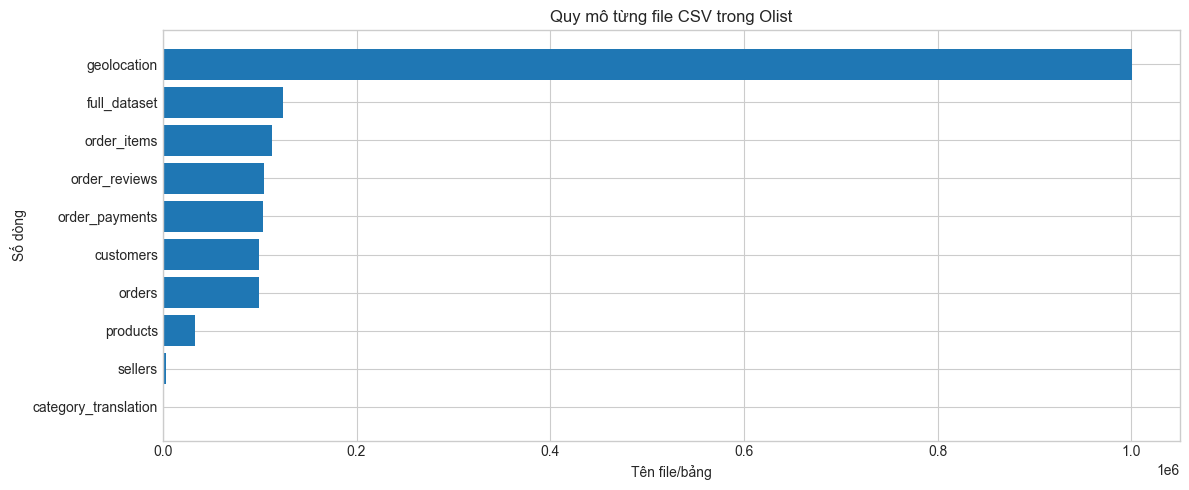

In [18]:
# Gom lại các DataFrame raw sau khi đã load riêng từng file
raw_tables = {}
for table_name in [
    "customers",
    "orders",
    "order_items",
    "order_payments",
    "order_reviews",
    "products",
    "sellers",
    "geolocation",
    "category_translation",
    "full_dataset",
]:
    if table_name in globals():
        raw_tables[table_name] = globals()[table_name]

if not raw_tables:
    raise ValueError("raw_tables is empty. Hãy chạy lại các cell load dữ liệu của Command 2 trước.")

table_summary_rows = []
for table_name, df in raw_tables.items():
    table_summary_rows.append((table_name, df.count(), len(df.columns), str(DATA_DIR / TABLE_FILES[table_name])))

table_summary_df = create_spark_df_from_rows(
    table_summary_rows,
    ["table_name", "row_count", "column_count", "file_path"],
).orderBy(F.desc("row_count"), F.asc("table_name"))


plot_bar_from_spark(table_summary_df.limit(10), "table_name", "row_count", "Quy mô từng file CSV trong Olist", "Tên file/bảng", "Số dòng", 20, horizontal=True)


### 4.1.3. Quan hệ giữa các bảng dữ liệu


[COMMAND_SO]
Command 3

[COMMAND_MUC_DICH]
- Mục tiêu nghiệp vụ: Chuẩn hóa kiểu dữ liệu để tránh sai lệch phân tích.
- Mục tiêu kỹ thuật: Cast các cột thời gian và numeric quan trọng, tạo data dictionary kỹ thuật.
- Command này hỗ trợ trực tiếp cho mục 4.2.2.


**[C3-1] Cast kiểu dữ liệu cho 4 bảng quan trọng**

Các bảng này có cột cần cast vì `inferSchema` không tự nhận đúng:
- `orders_typed`: 5 cột timestamp string → `TimestampType` bằng `F.to_timestamp()`.
- `order_items_typed`: `price`, `freight_value` → `DoubleType`; `shipping_limit_date` → timestamp.
- `order_payments_typed`: `payment_sequential`, `payment_installments` → `IntegerType`; `payment_value` → `DoubleType`.
- `order_reviews_typed`: `review_score` → `IntegerType`; 2 cột ngày → timestamp.
- Gom vào `typed_tables` dict để các command tiếp theo có một nguồn thống nhất.


In [19]:
# Command 3 - Chuẩn hóa kiểu dữ liệu và lập data dictionary kỹ thuật
required_raw_tables = [
    "customers",
    "orders",
    "order_items",
    "order_payments",
    "order_reviews",
    "products",
    "sellers",
    "geolocation",
    "category_translation",
    "full_dataset",
]
if "raw_tables" not in globals() or not isinstance(raw_tables, dict):
    raw_tables = {}

for table_name in required_raw_tables:
    if table_name not in raw_tables and table_name in globals():
        raw_tables[table_name] = globals()[table_name]

missing_required = [
    t for t in ["orders", "order_items", "order_payments", "order_reviews", "customers", "products", "sellers", "geolocation"]
    if t not in raw_tables
]
if missing_required:
    raise KeyError(
        f"Thiếu bảng trong raw_tables: {missing_required}. Hãy chạy lại các cell load tương ứng ở Command 2 trước."
    )

if "category_translation" not in raw_tables and "product_category_name_translation.csv" in str(TABLE_FILES.get("category_translation", "")):
    raw_tables["category_translation"] = spark.read.option("header", True).option("inferSchema", True).csv(str(DATA_DIR / TABLE_FILES["category_translation"]))
if "full_dataset" not in raw_tables and "full_dataset" in TABLE_FILES:
    raw_tables["full_dataset"] = spark.read.option("header", True).option("inferSchema", True).csv(str(DATA_DIR / TABLE_FILES["full_dataset"]))

orders_typed = (
    raw_tables["orders"]
    .withColumn("order_purchase_timestamp", F.to_timestamp("order_purchase_timestamp"))
    .withColumn("order_approved_at", F.to_timestamp("order_approved_at"))
    .withColumn("order_delivered_carrier_date", F.to_timestamp("order_delivered_carrier_date"))
    .withColumn("order_delivered_customer_date", F.to_timestamp("order_delivered_customer_date"))
    .withColumn("order_estimated_delivery_date", F.to_timestamp("order_estimated_delivery_date"))
)

order_items_typed = (
    raw_tables["order_items"]
    .withColumn("shipping_limit_date", F.to_timestamp("shipping_limit_date"))
    .withColumn("price", F.col("price").cast("double"))
    .withColumn("freight_value", F.col("freight_value").cast("double"))
)

order_payments_typed = (
    raw_tables["order_payments"]
    .withColumn("payment_sequential", F.col("payment_sequential").cast("int"))
    .withColumn("payment_installments", F.col("payment_installments").cast("int"))
    .withColumn("payment_value", F.col("payment_value").cast("double"))
)

order_reviews_typed = (
    raw_tables["order_reviews"]
    .withColumn("review_score", F.col("review_score").cast("int"))
    .withColumn("review_creation_date", F.to_timestamp("review_creation_date"))
    .withColumn("review_answer_timestamp", F.to_timestamp("review_answer_timestamp"))
)

typed_tables = {
    "customers": raw_tables["customers"],
    "orders": orders_typed,
    "order_items": order_items_typed,
    "order_payments": order_payments_typed,
    "order_reviews": order_reviews_typed,
    "products": raw_tables["products"],
    "sellers": raw_tables["sellers"],
    "geolocation": raw_tables["geolocation"],
    "category_translation": raw_tables["category_translation"],
    "full_dataset": raw_tables["full_dataset"],
}


**[C3-2] Xây dựng Data Dictionary kỹ thuật**

- Duyệt qua tất cả bảng trong `typed_tables`, với mỗi cột:
  - Lấy `spark_type` từ schema (sau khi đã cast).
  - Phân loại `semantic_group` bằng hàm `classify_columns()` đã định nghĩa ở C1-4.
- Tạo `column_dictionary_df` (Spark DataFrame) với 4 cột: `table_name`, `column_name`, `spark_type`, `semantic_group`.
- `.show(300)` để in toàn bộ dictionary — tài liệu tham chiếu kỹ thuật cho feature engineering.


In [20]:

dictionary_rows = []
for table_name, df in typed_tables.items():
    groups = classify_columns(df)
    for field in df.schema.fields:
        if field.name in groups["datetime_cols"]:
            semantic_group = "datetime"
        elif field.name in groups["numeric_cols"]:
            semantic_group = "numeric"
        elif field.name in groups["text_cols"]:
            semantic_group = "text"
        else:
            semantic_group = "categorical"
        dictionary_rows.append((table_name, field.name, field.dataType.simpleString(), semantic_group))

column_dictionary_df = create_spark_df_from_rows(
    dictionary_rows,
    ["table_name", "column_name", "spark_type", "semantic_group"],
).orderBy("table_name", "column_name")

column_dictionary_df.show(300, truncate=False)


+--------------------+-----------------------------+----------+--------------+
|table_name          |column_name                  |spark_type|semantic_group|
+--------------------+-----------------------------+----------+--------------+
|category_translation|product_category_name        |string    |categorical   |
|category_translation|product_category_name_english|string    |categorical   |
|customers           |customer_city                |string    |categorical   |
|customers           |customer_id                  |string    |categorical   |
|customers           |customer_state               |string    |categorical   |
|customers           |customer_unique_id           |string    |categorical   |
|customers           |customer_zip_code_prefix     |int       |numeric       |
|full_dataset        |customer_city                |string    |categorical   |
|full_dataset        |customer_id                  |string    |categorical   |
|full_dataset        |customer_state               |

[COMMAND_GIAI_THÍCH_CODE]
- Command này cast lại các cột thời gian và numeric quan trọng sau khi đã load từng file riêng lẻ.
- `column_dictionary_df` có grain 1 dòng = 1 cột trong 1 bảng, giúp bạn mô tả kiểu dữ liệu và nhóm thuộc tính trong báo cáo.
- Từ đây notebook sẽ dùng `typed_tables` thay cho `raw_tables` ở những bước cần tính toán thời gian và giá trị số.

[COMMAND_PHÂN_TÍCH_DỮ_LIỆU_VÀ_INSIGHT]
- Cách đọc output khi chạy: kiểm tra các cột ngày giờ đã thành `timestamp`, cột giá trị thanh toán/giá/freight đã thành `double`, review score đã thành `int`.
- Insight kỳ vọng: dữ liệu typed sẽ ổn định hơn cho EDA và preprocessing, đặc biệt ở các phần logistics, payment và reviews.
- Rủi ro dữ liệu cần chú ý: một số cột tên sai chính tả như `product_name_lenght` chưa đổi tên ở notebook 01 vì đây mới là pha khảo sát, chưa phải preprocessing.

[KẾT_LUẬN_CHO_FEATURE_ENGINEERING]
- 1. Feature có thể tạo tiếp theo: lead time, delay, payment value, text length.
- 2. Cột rủi ro leakage hoặc chất lượng thấp: review và delivery columns nếu dùng sai thời điểm.
- 3. Bảng/dataset nên materialize cho bước sau: `typed_tables`, `column_dictionary_df`.


[COMMAND_SO]
Command 4

[COMMAND_MUC_DICH]
- Mục tiêu nghiệp vụ: Profiling tổng hợp quy mô, null và duplicate theo bảng.
- Mục tiêu kỹ thuật: Tạo `profile_df`, `primary_key_check_df` và visualize quy mô dữ liệu.
- Command này bám mục 4.2.1 đến 4.2.4.


**[C4-1] Định nghĩa candidate primary keys**

Dict `candidate_primary_keys` liệt kê cột (hoặc tổ hợp cột) ứng viên làm khóa chính cho mỗi bảng.
Ví dụ:
- `orders` → `order_id` (dự kiến unique).
- `order_items` → `(order_id, order_item_id)` (khóa phức hợp).
- `geolocation` → `(zip_code_prefix, city, state)` — không có single-column primary key thực sự.

Danh sách này sẽ được dùng để chạy **primary key check** ở bước tiếp theo.


In [21]:
# Command 4 - Profiling tổng hợp sau khi đã đọc từng file và cast schema quan trọng
candidate_primary_keys = {
    "customers": ["customer_id", "customer_unique_id"],
    "orders": ["order_id"],
    "order_items": ["order_id", "order_item_id"],
    "order_payments": ["order_id", "payment_sequential"],
    "order_reviews": ["review_id", "order_id"],
    "products": ["product_id"],
    "sellers": ["seller_id"],
    "geolocation": ["geolocation_zip_code_prefix", "geolocation_city", "geolocation_state"],
    "category_translation": ["product_category_name"],
}


**[C4-2] Profiling tổng hợp — row count, duplicate, null, primary key**

Vòng `for` chạy qua tất cả bảng trong `typed_tables` và tính:
- `profile_rows`: `(table_name, row_count, col_count, distinct_rows, duplicate_rows, total_nulls)`.
- `primary_key_rows`: `(table_name, key_col, row_count, distinct_key, null_key)` cho mỗi candidate key.

Sau đó tạo:
- `profile_df`: bảng tổng quan quy mô dataset.
- `primary_key_check_df`: bảng kiểm tra key với cột `is_strong_primary_key_candidate`
  = `True` khi `row_count == distinct_key_count` và `null_key_count == 0`.
- 2 biểu đồ bar: so sánh `row_count` và `duplicate_row_count` giữa các bảng.


+--------------------+---------+------------+------------------+-------------------+-----------------+
|table_name          |row_count|column_count|distinct_row_count|duplicate_row_count|total_null_values|
+--------------------+---------+------------+------------------+-------------------+-----------------+
|geolocation         |1000163  |5           |738332            |261831             |0                |
|full_dataset        |124534   |40          |123178            |1356               |435915           |
|order_items         |112650   |7           |112650            |0                  |0                |
|order_reviews       |104162   |7           |104071            |91                 |180043           |
|order_payments      |103886   |5           |103886            |0                  |0                |
|customers           |99441    |5           |99441             |0                  |0                |
|orders              |99441    |8           |99441             |0        

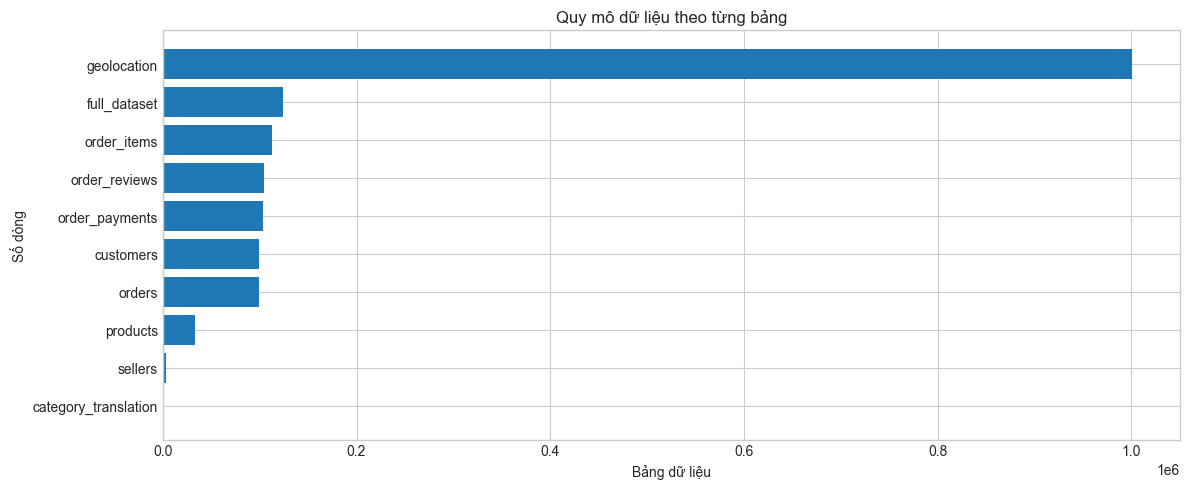

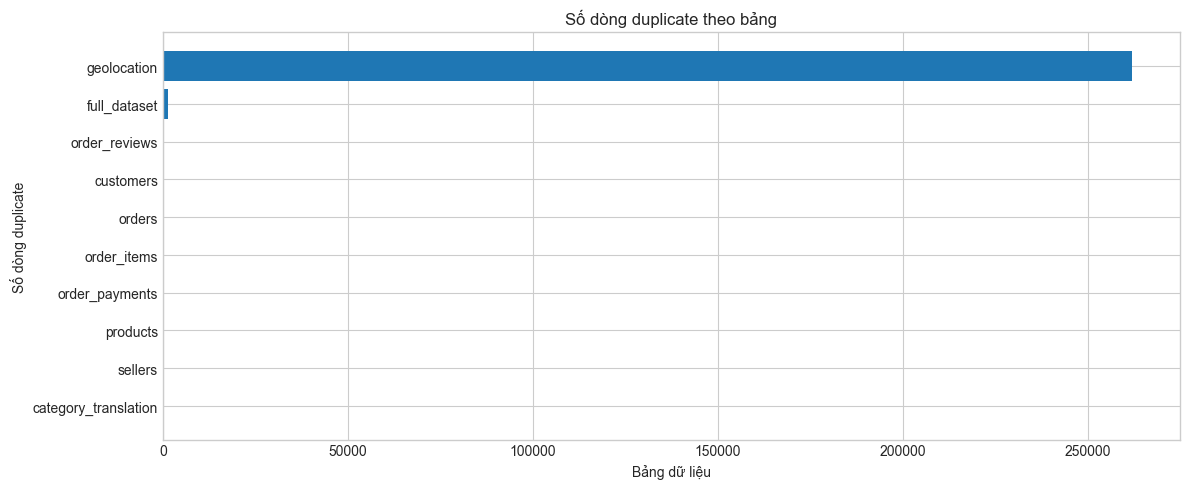

In [22]:

profile_rows = []
primary_key_rows = []

for table_name, df in typed_tables.items():
    row_count = df.count()
    distinct_row_count = df.distinct().count()
    duplicate_row_count = row_count - distinct_row_count
    null_count_total = sum(row["null_count"] for row in build_null_profile(df).select("null_count").collect())
    profile_rows.append((table_name, row_count, len(df.columns), distinct_row_count, duplicate_row_count, null_count_total))

    for key_col in candidate_primary_keys.get(table_name, []):
        if key_col in df.columns:
            distinct_key_count = df.select(key_col).distinct().count()
            null_key_count = df.filter(F.col(key_col).isNull()).count()
            primary_key_rows.append((table_name, key_col, row_count, distinct_key_count, null_key_count))

profile_df = create_spark_df_from_rows(
    profile_rows,
    ["table_name", "row_count", "column_count", "distinct_row_count", "duplicate_row_count", "total_null_values"],
).orderBy(F.desc("row_count"))

primary_key_check_df = create_spark_df_from_rows(
    primary_key_rows,
    ["table_name", "candidate_key", "row_count", "distinct_key_count", "null_key_count"],
).withColumn(
    "is_strong_primary_key_candidate",
    F.when((F.col("row_count") == F.col("distinct_key_count")) & (F.col("null_key_count") == 0), 1).otherwise(0),
).orderBy("table_name", "candidate_key")

profile_df.show(truncate=False)
primary_key_check_df.show(truncate=False)

plot_bar_from_spark(profile_df.orderBy(F.desc("row_count")), "table_name", "row_count", "Quy mô dữ liệu theo từng bảng", "Bảng dữ liệu", "Số dòng", 20, horizontal=True)
plot_bar_from_spark(profile_df.orderBy(F.desc("duplicate_row_count")), "table_name", "duplicate_row_count", "Số dòng duplicate theo bảng", "Bảng dữ liệu", "Số dòng duplicate", 20, horizontal=True)


[COMMAND_GIAI_THÍCH_CODE]
- Command này tổng hợp lại tình trạng dữ liệu sau khi từng file đã được đọc riêng và một số bảng đã được cast schema.
- `profile_df` có grain 1 dòng = 1 bảng; `primary_key_check_df` có grain 1 dòng = 1 khóa khả nghi trong 1 bảng.
- Hai biểu đồ đi kèm giúp bạn nhìn nhanh bảng nào lớn nhất và bảng nào có rủi ro duplicate cao nhất.

[COMMAND_PHÂN_TÍCH_DỮ_LIỆU_VÀ_INSIGHT]
- Cách đọc output khi chạy: nhìn `row_count`, `duplicate_row_count`, `total_null_values` và tính hợp lệ của khóa chính khả nghi.
- Insight kỳ vọng: `geolocation` sẽ nổi bật về quy mô và duplicate risk; `orders` và `customers` gần nhau về row count; `order_items` lớn hơn `orders` vì là grain item-level.
- Rủi ro dữ liệu cần chú ý: `customer_unique_id` không phải khóa chính vật lý của bảng `customers`, chỉ là business key ở customer-level.

[KẾT_LUẬN_CHO_FEATURE_ENGINEERING]
- 1. Feature có thể tạo tiếp theo: duplicate flags, null flags, density features theo bảng.
- 2. Cột rủi ro leakage hoặc chất lượng thấp: chưa phải leakage trực tiếp, nhưng key sai grain sẽ gây lỗi feature nặng.
- 3. Bảng/dataset nên materialize cho bước sau: `profile_df`, `primary_key_check_df`.


[COMMAND_SO]
Command 5

[COMMAND_MUC_DICH]
- Mục tiêu nghiệp vụ: Hiểu rõ quan hệ giữa các bảng và grain dữ liệu.
- Mục tiêu kỹ thuật: Tạo `relationship_df`, `grain_df` và xác định join strategy an toàn.
- Command này bám mục 4.1.3.


**[C5-1] Kiểm tra join key relationships**

`relationship_specs` khai báo 7 quan hệ giữa các bảng (left_table, right_table, join_key).
Vòng `for` tính 2 con số quan trọng:
- `left_distinct_key`: số giá trị distinct của join_key trong bảng bên trái.
- `right_distinct_key`: số giá trị distinct trong bảng bên phải.

Nếu `left_distinct_key > right_distinct_key` → bảng phải có orphan keys → join sẽ tạo null.
Nếu `left_distinct_key << right_distinct_key` → bảng trái thiếu nhiều keys → cân nhắc inner vs left join.


In [23]:
# Command 5 - Quan hệ giữa các bảng, join key và grain
relationship_specs = [
    ("orders", "customers", "customer_id"),
    ("order_items", "orders", "order_id"),
    ("order_payments", "orders", "order_id"),
    ("order_reviews", "orders", "order_id"),
    ("order_items", "products", "product_id"),
    ("order_items", "sellers", "seller_id"),
    ("products", "category_translation", "product_category_name"),
]

relationship_rows = []
for left_table, right_table, join_key in relationship_specs:
    left_df = typed_tables[left_table]
    right_df = typed_tables[right_table]
    relationship_rows.append(
        (
            left_table,
            right_table,
            join_key,
            left_df.count(),
            right_df.count(),
            left_df.select(join_key).distinct().count(),
            right_df.select(join_key).distinct().count(),
        )
    )

relationship_df = create_spark_df_from_rows(
    relationship_rows,
    ["left_table", "right_table", "join_key", "left_rows", "right_rows", "left_distinct_keys", "right_distinct_keys"],
)


**[C5-2] Định nghĩa Grain Dictionary**

`grain_df` mô tả chính xác grain (đơn vị một dòng dữ liệu) của từng bảng:
- Thông tin này rất quan trọng khi join — join sai grain sẽ gây row explosion.
- Ví dụ: `order_items` có grain order-item-level → join thẳng vào orders sẽ duplicate orders.
- Đây là tài liệu tham chiếu cho **bước aggregate trước khi join** ở notebook 02.


In [24]:
relationship_df.show(truncate=False)

grain_df = create_spark_df_from_rows(
    [
        ("customers", "customer_id-level row; customer business entity tracked by customer_unique_id", "customer_id"),
        ("orders", "order-level row", "order_id"),
        ("order_items", "order-item-level row", "order_id + order_item_id"),
        ("order_payments", "payment-line within order", "order_id + payment_sequential"),
        ("order_reviews", "review-level row linked to order", "review_id"),
        ("products", "product-level row", "product_id"),
        ("sellers", "seller-level row", "seller_id"),
        ("geolocation", "zip/city/state geolocation observation", "no strict single-column key"),
        ("category_translation", "lookup row", "product_category_name"),
    ],
    ["table_name", "grain_definition", "candidate_key"],
)
grain_df.show(truncate=False)


+--------------+--------------------+---------------------+---------+----------+------------------+-------------------+
|left_table    |right_table         |join_key             |left_rows|right_rows|left_distinct_keys|right_distinct_keys|
+--------------+--------------------+---------------------+---------+----------+------------------+-------------------+
|orders        |customers           |customer_id          |99441    |99441     |99441             |99441              |
|order_items   |orders              |order_id             |112650   |99441     |98666             |99441              |
|order_payments|orders              |order_id             |103886   |99441     |99440             |99441              |
|order_reviews |orders              |order_id             |104162   |99441     |99743             |99441              |
|order_items   |products            |product_id           |112650   |32951     |32951             |32951              |
|order_items   |sellers             |sel

[COMMAND_GIAI_THÍCH_CODE]
- `relationship_df` tóm tắt các quan hệ join quan trọng giữa bảng với bảng; `grain_df` là bảng giải thích grain chính thức của từng file.
- Đây là chỗ chốt sự khác nhau giữa `customer_id` và `customer_unique_id`, giữa grain order-level và order-item-level.
- Không có visualize nặng ở đây vì trọng tâm là logic quan hệ và join strategy.

[COMMAND_PHÂN_TÍCH_DỮ_LIỆU_VÀ_INSIGHT]
- Cách đọc output khi chạy: kiểm tra bảng nào là 1-n theo `order_id`, bảng lookup nào đủ nhỏ và bảng nào không nên join trực tiếp.
- Insight kỳ vọng: `order_items`, `order_payments`, `order_reviews` đều là nguồn 1-n theo `order_id`, nên phải aggregate trước khi build bảng master ở grain order-level.
- Rủi ro dữ liệu cần chú ý: `geolocation` nếu join trực tiếp sẽ làm nổ số dòng; chỉ nên aggregate hoặc deduplicate trước.

[KẾT_LUẬN_CHO_FEATURE_ENGINEERING]
- 1. Feature có thể tạo tiếp theo: item aggregate, payment aggregate, review aggregate, customer history.
- 2. Cột rủi ro leakage hoặc chất lượng thấp: các cột hậu vận hành nếu bị đẩy lên order-level mà không kiểm soát thời điểm.
- 3. Bảng/dataset nên materialize cho bước sau: `relationship_df`, `grain_df`.


## 4.2.5. Kiểm tra giá trị ngoại lệ và dữ liệu nhiễu


[COMMAND_SO]
Command 6

[COMMAND_MUC_DICH]
- Mục tiêu nghiệp vụ: Phát hiện dữ liệu lỗi và ngoại lệ có thể ảnh hưởng đến EDA.
- Mục tiêu kỹ thuật: Audit invalid values, outliers và visualize số lượng lỗi theo cột.
- Command này bám mục 4.2.5.


**[C6-1] Kiểm tra invalid values theo business rules**

Audit các giá trị vi phạm business logic:
- `review_score` ngoài miền [1, 5] → invalid ordinal score.
- `price <= 0` và `freight_value < 0` trong `order_items` → giá âm không hợp lý.
- `payment_value <= 0` → giao dịch không có giá trị thực.
- `product_weight_g`, `product_length/height/width_cm <= 0` → kích thước vô lý.

Kết quả: `quality_rule_df` với `issue_count` và `issue_ratio` cho từng rule + biểu đồ.


+--------------+-----------------+--------------------+-----------+---------+---------------------+
|table_name    |column_name      |rule_name           |issue_count|row_count|issue_ratio          |
+--------------+-----------------+--------------------+-----------+---------+---------------------+
|products      |product_weight_g |invalid_numeric_rule|4          |32951    |1.2139237048951474E-4|
|order_payments|payment_value    |invalid_numeric_rule|9          |103886   |8.663342510059104E-5 |
|order_reviews |review_score     |outside_1_5         |3          |104162   |2.880129029780534E-5 |
|order_items   |price            |invalid_numeric_rule|0          |112650   |0.0                  |
|order_items   |freight_value    |invalid_numeric_rule|0          |112650   |0.0                  |
|products      |product_length_cm|invalid_numeric_rule|0          |32951    |0.0                  |
|products      |product_height_cm|invalid_numeric_rule|0          |32951    |0.0                  |


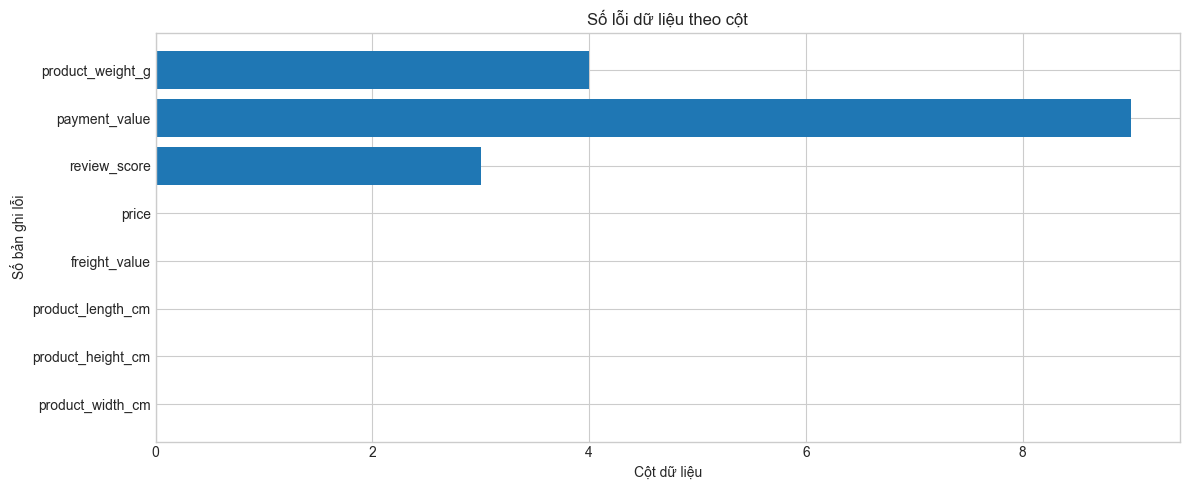

In [25]:
# Command 6 - Audit invalid values, outliers và dữ liệu nhiễu
rule_rows = []

invalid_review_score = order_reviews_typed.filter(F.col("review_score").isNotNull() & (~F.col("review_score").between(1, 5))).count()
rule_rows.append(("order_reviews", "review_score", "outside_1_5", invalid_review_score, order_reviews_typed.count()))

for table_name, column_name, condition in [
    ("order_items", "price", F.col("price") <= 0),
    ("order_items", "freight_value", F.col("freight_value") < 0),
    ("order_payments", "payment_value", F.col("payment_value") <= 0),
    ("products", "product_weight_g", F.col("product_weight_g") <= 0),
    ("products", "product_length_cm", F.col("product_length_cm") <= 0),
    ("products", "product_height_cm", F.col("product_height_cm") <= 0),
    ("products", "product_width_cm", F.col("product_width_cm") <= 0),
]:
    df = typed_tables[table_name]
    invalid_count = df.filter(F.col(column_name).isNotNull() & condition).count()
    rule_rows.append((table_name, column_name, "invalid_numeric_rule", invalid_count, df.count()))

quality_rule_df = create_spark_df_from_rows(
    rule_rows,
    ["table_name", "column_name", "rule_name", "issue_count", "row_count"],
).withColumn("issue_ratio", F.when(F.col("row_count") > 0, F.col("issue_count") / F.col("row_count")).otherwise(F.lit(0.0)))

quality_rule_df.orderBy(F.desc("issue_ratio"), F.desc("issue_count")).show(truncate=False)
plot_bar_from_spark(quality_rule_df.orderBy(F.desc("issue_ratio")), "column_name", "issue_count", "Số lỗi dữ liệu theo cột", "Cột dữ liệu", "Số bản ghi lỗi", 20, horizontal=True)


**[C6-2] Phân tích phân phối outlier (IQR)**

Tính các phân vị `Q1`, `median`, `Q3`, `P99` cho 4 cột số quan trọng:
- `order_items.price`, `order_items.freight_value`
- `order_payments.payment_value`, `products.product_weight_g`

**IQR method**: outlier khi `x < Q1 - 1.5×IQR` hoặc `x > Q3 + 1.5×IQR`.
So sánh `Q3` với `P99` để hiểu mức độ phân phối lệch (heavy tail).
Dataset Olist thường có long tail mạnh ở price và freight.


In [26]:

outlier_rows = []
for table_name, column_name in [
    ("order_items", "price"),
    ("order_items", "freight_value"),
    ("order_payments", "payment_value"),
    ("products", "product_weight_g"),
]:
    df = typed_tables[table_name]
    stats = df.select(
        F.expr(f"percentile_approx({column_name}, 0.25)").alias("q1"),
        F.expr(f"percentile_approx({column_name}, 0.50)").alias("median"),
        F.expr(f"percentile_approx({column_name}, 0.75)").alias("q3"),
        F.expr(f"percentile_approx({column_name}, 0.99)").alias("p99"),
    ).collect()[0]
    outlier_rows.append((table_name, column_name, stats["q1"], stats["median"], stats["q3"], stats["p99"]))

outlier_summary_df = create_spark_df_from_rows(outlier_rows, ["table_name", "column_name", "q1", "median", "q3", "p99"])
outlier_summary_df.show(truncate=False)


+--------------+----------------+------+------+-------+--------+
|table_name    |column_name     |q1    |median|q3     |p99     |
+--------------+----------------+------+------+-------+--------+
|order_items   |price           |39.90 |74.99 |134.90 |889.00  |
|order_items   |freight_value   |13.08 |16.26 |21.15  |84.15   |
|order_payments|payment_value   |56.79 |100.00|171.79 |1036.74 |
|products      |product_weight_g|300.00|700.00|1900.00|22450.00|
+--------------+----------------+------+------+-------+--------+



[COMMAND_GIAI_THÍCH_CODE]
- Command này kiểm tra các rule invalid cơ bản theo cột numeric và review score, sau đó mô tả outlier sơ bộ bằng percentile.
- `quality_rule_df` có grain 1 dòng = 1 rule trên 1 cột; `outlier_summary_df` có grain 1 dòng = 1 cột numeric cần kiểm tra phân phối.
- Biểu đồ đi kèm giúp nhìn nhanh cột nào phát sinh nhiều issue nhất.

[COMMAND_PHÂN_TÍCH_DỮ_LIỆU_VÀ_INSIGHT]
- Cách đọc output khi chạy: nhìn `issue_ratio`, `issue_count` và khoảng cách giữa `median` với `p99`.
- Insight kỳ vọng: `price`, `payment_value`, `product_weight_g` thường lệch phải; `review_score` về lý thuyết chỉ nên nằm trong 1-5.
- Rủi ro dữ liệu cần chú ý: outlier rất mạnh sẽ làm méo mean và ảnh hưởng đến StandardScaler nếu không xử lý ở preprocessing.

[KẾT_LUẬN_CHO_FEATURE_ENGINEERING]
- 1. Feature có thể tạo tiếp theo: invalid flags, log-transform candidates, outlier caps.
- 2. Cột rủi ro leakage hoặc chất lượng thấp: review-related features nếu target cũng là review outcome.
- 3. Bảng/dataset nên materialize cho bước sau: `quality_rule_df`, `outlier_summary_df`.


[COMMAND_SO]
Command 7

[COMMAND_MUC_DICH]
- Mục tiêu nghiệp vụ: Kiểm tra logic thời gian và rủi ro leakage.
- Mục tiêu kỹ thuật: Audit timeline của orders và tạo bảng leakage reference.
- Command này hỗ trợ mục 4.2.5 và chuẩn bị cho modeling sau này.


**[C7-1] Audit logic thứ tự thời gian trong orders**

Kiểm tra 5 vi phạm logic timeline (mỗi cái tạo một flag nhị phân):

| Flag | Vi phạm logic |
|------|---------------|
| `approved_before_purchase_flag` | Đơn duyệt trước khi đặt |
| `carrier_before_purchase_flag` | Giao carrier trước khi đặt |
| `delivered_before_purchase_flag` | Giao khách trước khi đặt |
| `delivered_before_carrier_flag` | Giao khách trước khi giao carrier |
| `estimated_before_purchase_flag` | Ngày dự kiến trước khi đặt |

`time_audit_summary_df`: đếm tổng số vi phạm của mỗi loại — dùng để quyết định drop hay giữ những đơn có timestamp bất thường.


In [27]:
# Command 7 - Audit logic thời gian và cảnh báo leakage
orders_time_audit_df = (
    orders_typed
    .withColumn("approved_before_purchase_flag", F.when(F.col("order_approved_at") < F.col("order_purchase_timestamp"), 1).otherwise(0))
    .withColumn("carrier_before_purchase_flag", F.when(F.col("order_delivered_carrier_date") < F.col("order_purchase_timestamp"), 1).otherwise(0))
    .withColumn("delivered_before_purchase_flag", F.when(F.col("order_delivered_customer_date") < F.col("order_purchase_timestamp"), 1).otherwise(0))
    .withColumn("delivered_before_carrier_flag", F.when(F.col("order_delivered_customer_date") < F.col("order_delivered_carrier_date"), 1).otherwise(0))
    .withColumn("estimated_before_purchase_flag", F.when(F.col("order_estimated_delivery_date") < F.col("order_purchase_timestamp"), 1).otherwise(0))
)

time_audit_summary_df = orders_time_audit_df.agg(
    F.sum("approved_before_purchase_flag").alias("approved_before_purchase"),
    F.sum("carrier_before_purchase_flag").alias("carrier_before_purchase"),
    F.sum("delivered_before_purchase_flag").alias("delivered_before_purchase"),
    F.sum("delivered_before_carrier_flag").alias("delivered_before_carrier"),
    F.sum("estimated_before_purchase_flag").alias("estimated_before_purchase"),
)
time_audit_summary_df.show(truncate=False)


+------------------------+-----------------------+-------------------------+------------------------+-------------------------+
|approved_before_purchase|carrier_before_purchase|delivered_before_purchase|delivered_before_carrier|estimated_before_purchase|
+------------------------+-----------------------+-------------------------+------------------------+-------------------------+
|0                       |166                    |0                        |23                      |0                        |
+------------------------+-----------------------+-------------------------+------------------------+-------------------------+



**[C7-2] Leakage Reference Table — bảng cảnh báo rủi ro leakage**

Phân loại từng cột quan trọng theo mức độ rủi ro leakage cho bài toán dự báo sớm:

| Level | Ý nghĩa |
|-------|----------|
| `safe_reference` | Có thể dùng tự do làm feature |
| `conditional` | An toàn chỉ khi bài toán diễn ra sau sự kiện đó |
| `high_leakage` | Biến outcome — **tuyệt đối không dùng** làm input cho dự báo sớm |

Bảng này là tài liệu tham chiếu cho notebook Feature Engineering (03) khi chọn features.


In [28]:

leakage_reference_df = create_spark_df_from_rows(
    [
        ("safe_reference", "order_purchase_timestamp", "Mốc gốc cho bài toán dự báo sớm"),
        ("conditional", "order_approved_at", "Chỉ an toàn nếu bài toán diễn ra sau khi đơn được duyệt"),
        ("high_leakage", "order_delivered_customer_date", "Biến hậu giao hàng"),
        ("high_leakage", "review_score", "Biến outcome hậu trải nghiệm"),
        ("high_leakage", "review_comment_message", "Text hậu trải nghiệm"),
    ],
    ["leakage_level", "column_name", "note"],
)
leakage_reference_df.show(truncate=False)


+--------------+-----------------------------+-------------------------------------------------------+
|leakage_level |column_name                  |note                                                   |
+--------------+-----------------------------+-------------------------------------------------------+
|safe_reference|order_purchase_timestamp     |Mốc gốc cho bài toán dự báo sớm                        |
|conditional   |order_approved_at            |Chỉ an toàn nếu bài toán diễn ra sau khi đơn được duyệt|
|high_leakage  |order_delivered_customer_date|Biến hậu giao hàng                                     |
|high_leakage  |review_score                 |Biến outcome hậu trải nghiệm                           |
|high_leakage  |review_comment_message       |Text hậu trải nghiệm                                   |
+--------------+-----------------------------+-------------------------------------------------------+



[COMMAND_GIAI_THÍCH_CODE]
- Command này audit các vi phạm logic theo timeline của orders và tạo bảng tham chiếu leakage cho các cột hậu vận hành.
- `time_audit_summary_df` ở grain tổng hợp toàn bộ; `leakage_reference_df` ở grain 1 dòng = 1 cột/cụm cột cần cảnh báo.
- Đây là bước bắt buộc trước khi nghĩ đến supervised learning.

[COMMAND_PHÂN_TÍCH_DỮ_LIỆU_VÀ_INSIGHT]
- Cách đọc output khi chạy: nếu các cờ vi phạm thời gian khác 0 thì phải xem như dữ liệu lỗi hoặc ít nhất là edge cases cần gắn cờ.
- Insight kỳ vọng: phần lớn đơn hợp lệ sẽ đi đúng thứ tự thời gian; số ít bản ghi đảo mốc là tín hiệu dữ liệu cần làm sạch.
- Rủi ro dữ liệu cần chú ý: review và delivery là nguồn leakage rất mạnh cho mọi bài toán dự báo tại thời điểm mua.

[KẾT_LUẬN_CHO_FEATURE_ENGINEERING]
- 1. Feature có thể tạo tiếp theo: approval lag, violation flags.
- 2. Cột rủi ro leakage hoặc chất lượng thấp: toàn bộ review/delivery timestamps cho early prediction.
- 3. Bảng/dataset nên materialize cho bước sau: `time_audit_summary_df`, `leakage_reference_df`.


## 4.3. Phân tích khám phá dữ liệu (EDA)

Các command dưới đây đều có visualize, nhưng chỉ sau khi đã aggregate dữ liệu bằng Spark.


### 4.3.1. Phân bố đơn hàng theo thời gian


[COMMAND_SO]
Command 8

[COMMAND_MUC_DICH]
- Mục tiêu nghiệp vụ: Quan sát xu hướng đơn hàng theo thời gian.
- Mục tiêu kỹ thuật: Aggregate orders theo tháng và visualize line chart.
- Command này bám mục 4.3.1.


**[C8] Phân bố đơn hàng theo thời gian**

- `orders_monthly_df`: groupBy `(year, month)` đếm số đơn và tính doanh thu theo tháng.
- `F.date_format(order_purchase_timestamp, 'yyyy-MM')` tạo cột chuỗi `'YYYY-MM'` để sort và plot.
- **Line chart** thể hiện 2 series: `order_count` và `order_revenue` theo thời gian.
- **Insight kỳ vọng**: tăng trưởng mạnh cuối 2017 – đầu 2018; seasonal spike tháng 11 (Black Friday Brazil).
- Insight này trực tiếp hỗ trợ tạo `month`, `weekday`, `seasonal_bucket` features ở notebook 03.


+----------+------------+----------------+
|year_month|total_orders|delivered_orders|
+----------+------------+----------------+
|2016-09   |4           |1               |
|2016-10   |324         |265             |
|2016-12   |1           |1               |
|2017-01   |800         |750             |
|2017-02   |1780        |1653            |
|2017-03   |2682        |2546            |
|2017-04   |2404        |2303            |
|2017-05   |3700        |3546            |
|2017-06   |3245        |3135            |
|2017-07   |4026        |3872            |
|2017-08   |4331        |4193            |
|2017-09   |4285        |4150            |
|2017-10   |4631        |4478            |
|2017-11   |7544        |7289            |
|2017-12   |5673        |5513            |
|2018-01   |7269        |7069            |
|2018-02   |6728        |6555            |
|2018-03   |7211        |7003            |
|2018-04   |6939        |6798            |
|2018-05   |6873        |6749            |
|2018-06   

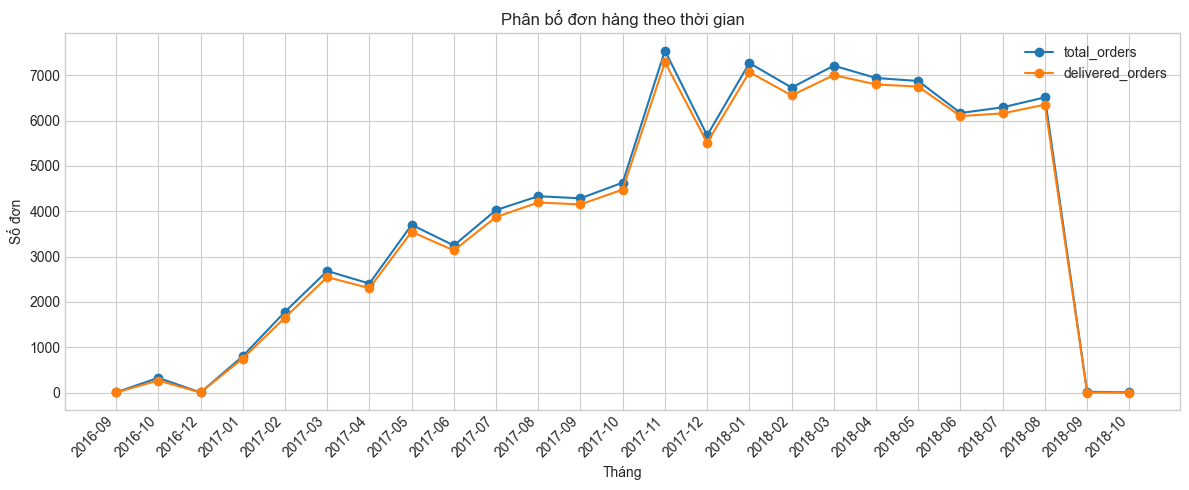

+----------+------------+-----------+
|year_month|order_status|order_count|
+----------+------------+-----------+
|2016-09   |canceled    |2          |
|2016-09   |delivered   |1          |
|2016-09   |shipped     |1          |
|2016-10   |canceled    |24         |
|2016-10   |delivered   |265        |
|2016-10   |invoiced    |18         |
|2016-10   |processing  |2          |
|2016-10   |shipped     |8          |
|2016-10   |unavailable |7          |
|2016-12   |delivered   |1          |
|2017-01   |canceled    |3          |
|2017-01   |delivered   |750        |
|2017-01   |invoiced    |12         |
|2017-01   |processing  |9          |
|2017-01   |shipped     |16         |
|2017-01   |unavailable |10         |
|2017-02   |approved    |1          |
|2017-02   |canceled    |17         |
|2017-02   |delivered   |1653       |
|2017-02   |invoiced    |11         |
|2017-02   |processing  |32         |
|2017-02   |shipped     |21         |
|2017-02   |unavailable |45         |
|2017-03   |

In [29]:
# Command 8 - Phân bố đơn hàng theo thời gian
orders_monthly_df = (
    orders_typed
    .filter(F.col("order_purchase_timestamp").isNotNull())
    .withColumn("year_month", F.date_format("order_purchase_timestamp", "yyyy-MM"))
    .groupBy("year_month")
    .agg(
        F.countDistinct("order_id").alias("total_orders"),
        F.countDistinct(F.when(F.col("order_status") == "delivered", F.col("order_id"))).alias("delivered_orders"),
    )
    .orderBy("year_month")
)
orders_monthly_df.show(50, truncate=False)
plot_line_from_spark(orders_monthly_df, "year_month", ["total_orders", "delivered_orders"], "Phân bố đơn hàng theo thời gian", "Tháng", "Số đơn")

orders_status_monthly_df = (
    orders_typed
    .filter(F.col("order_purchase_timestamp").isNotNull())
    .withColumn("year_month", F.date_format("order_purchase_timestamp", "yyyy-MM"))
    .groupBy("year_month", "order_status")
    .agg(F.countDistinct("order_id").alias("order_count"))
    .orderBy("year_month", "order_status")
)
orders_status_monthly_df.show(100, truncate=False)


[COMMAND_GIAI_THÍCH_CODE]
- `orders_monthly_df` aggregate dữ liệu về grain tháng để phân tích trend đơn hàng theo thời gian.
- `orders_status_monthly_df` cho phép đọc thêm biến động trạng thái đơn theo tháng.
- Biểu đồ line được tạo từ dữ liệu Spark đã aggregate, sau đó mới convert nhỏ sang pandas.

[COMMAND_PHÂN_TÍCH_DỮ_LIỆU_VÀ_INSIGHT]
- Cách đọc output khi chạy: quan sát điểm tăng/giảm mạnh, sự chênh lệch giữa `total_orders` và `delivered_orders`, và giai đoạn biến động của `order_status`.
- Insight kỳ vọng: dữ liệu có yếu tố tăng trưởng theo thời gian và có thể có seasonality, rất phù hợp để tạo time-based features.
- Rủi ro dữ liệu cần chú ý: các tháng biên đầu/cuối dataset có thể không đầy đủ, cần cẩn trọng khi diễn giải xu hướng.

[KẾT_LUẬN_CHO_FEATURE_ENGINEERING]
- 1. Feature có thể tạo tiếp theo: month, quarter, time index, seasonal bucket.
- 2. Cột rủi ro leakage hoặc chất lượng thấp: `order_status` nếu dùng sai mốc thời gian dự báo.
- 3. Bảng/dataset nên materialize cho bước sau: `orders_monthly_df`, `orders_status_monthly_df`.


### 4.3.5. Phân bố khách hàng theo bang và tần suất mua


[COMMAND_SO]
Command 9

[COMMAND_MUC_DICH]
- Mục tiêu nghiệp vụ: Hiểu hành vi mua của khách và phân bố địa lý khách hàng.
- Mục tiêu kỹ thuật: Tạo customer-level summary theo `customer_unique_id` và visualize frequency/state.
- Command này bám mục 4.3.5.


**[C9-1] Tổng hợp hành vi mua hàng của từng customer**

- Join `orders` ← `customers` theo `customer_id`.
- GroupBy `customer_unique_id` (không phải `customer_id`!):
  - `total_orders`, `first_purchase_ts`, `last_purchase_ts`, `customer_state`.
- **Tại sao phải dùng `customer_unique_id`?** Mỗi lần mua hàng tạo ra một `customer_id` mới;
  `customer_unique_id` mới là định danh thực sự của khách hàng qua nhiều đơn hàng.


In [30]:
# Command 9 - Phân tích khách hàng, tần suất mua và customer_unique_id
orders_customers_df = orders_typed.join(raw_tables["customers"], on="customer_id", how="left")

customer_summary_df = (
    orders_customers_df
    .groupBy("customer_unique_id")
    .agg(
        F.countDistinct("order_id").alias("total_orders"),
        F.min("order_purchase_timestamp").alias("first_purchase_ts"),
        F.max("order_purchase_timestamp").alias("last_purchase_ts"),
        F.first("customer_state", ignorenulls=True).alias("customer_state"),
    )
)
customer_summary_df.show(10, truncate=False)


+--------------------------------+------------+-------------------+-------------------+--------------+
|customer_unique_id              |total_orders|first_purchase_ts  |last_purchase_ts   |customer_state|
+--------------------------------+------------+-------------------+-------------------+--------------+
|0000f6ccb0745a6a4b88665a16c9f078|1           |2017-10-12 20:29:41|2017-10-12 20:29:41|PA            |
|0004aac84e0df4da2b147fca70cf8255|1           |2017-11-14 19:45:42|2017-11-14 19:45:42|SP            |
|00053a61a98854899e70ed204dd4bafe|1           |2018-02-28 11:15:41|2018-02-28 11:15:41|PR            |
|000c8bdb58a29e7115cfc257230fb21b|1           |2017-12-12 22:53:35|2017-12-12 22:53:35|MG            |
|000d460961d6dbfa3ec6c9f5805769e1|1           |2018-01-07 22:59:25|2018-01-07 22:59:25|SP            |
|000ec5bff359e1c0ad76a81a45cb598f|1           |2018-08-21 11:34:26|2018-08-21 11:34:26|SP            |
|000fbf0473c10fc1ab6f8d2d286ce20c|1           |2018-07-26 09:43:52|2018-0

**[C9-2] Phân tích tần suất mua & phân bố theo bang**

- `customer_frequency_df`: phân nhóm customer theo số đơn (`1`, `2-3`, `4-5`, `≥6`).
  Insight kỳ vọng: phần lớn khách chỉ mua 1 lần → one-time buyer dominance.
- `customer_state_df`: đếm unique customer theo bang (state).
  Insight kỳ vọng: São Paulo (SP) chiếm tỉ lệ lớn nhất — thể hiện tập trung địa lý.
- Cả hai được vẽ bar chart để trực quan hóa phân bố.


+----------------+--------------+
|frequency_bucket|customer_count|
+----------------+--------------+
|2-3 đơn         |2948          |
|4-5 đơn         |38            |
|>=6 đơn         |11            |
|1 đơn           |93099         |
+----------------+--------------+



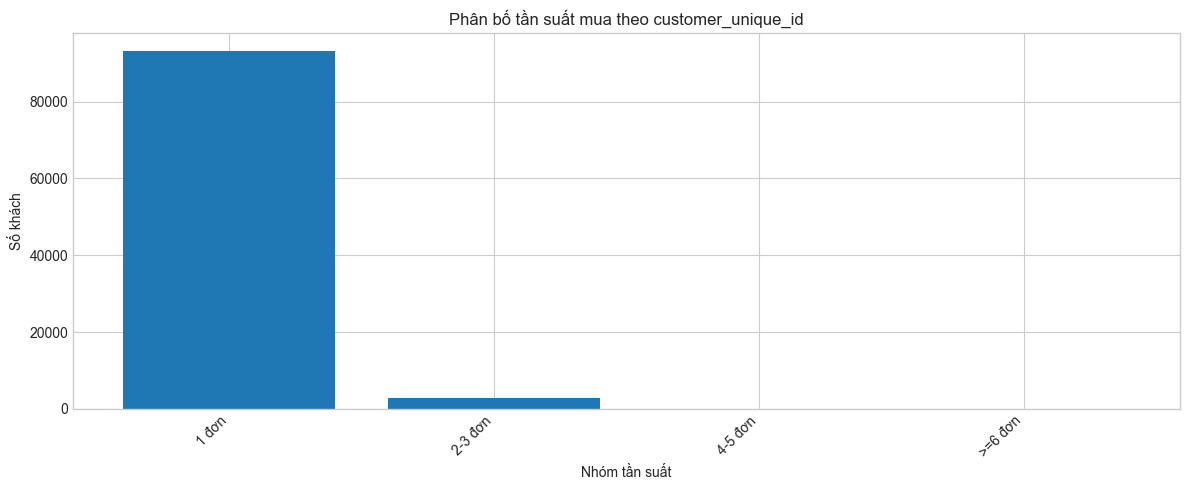

+--------------+----------------+
|customer_state|unique_customers|
+--------------+----------------+
|SP            |40296           |
|RJ            |12379           |
|MG            |11254           |
|RS            |5276            |
|PR            |4881            |
|SC            |3529            |
|BA            |3277            |
|DF            |2073            |
|ES            |1964            |
|GO            |1951            |
|PE            |1604            |
|CE            |1312            |
|PA            |949             |
|MT            |875             |
|MA            |725             |
|MS            |693             |
|PB            |518             |
|PI            |482             |
|RN            |474             |
|AL            |400             |
+--------------+----------------+
only showing top 20 rows



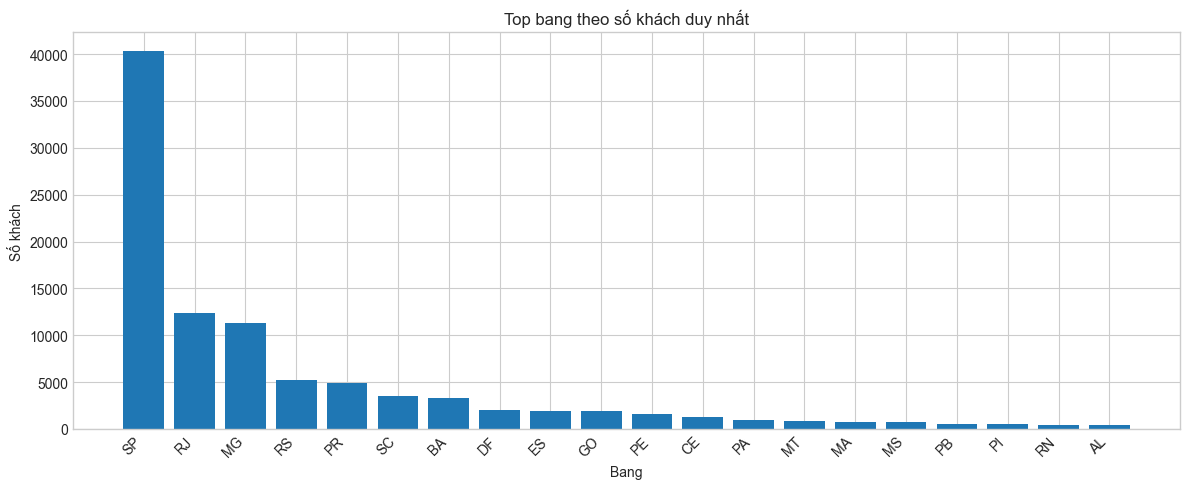

In [31]:

customer_frequency_df = (
    customer_summary_df
    .withColumn(
        "frequency_bucket",
        F.when(F.col("total_orders") == 1, "1 đơn")
        .when(F.col("total_orders").between(2, 3), "2-3 đơn")
        .when(F.col("total_orders").between(4, 5), "4-5 đơn")
        .otherwise(">=6 đơn"),
    )
    .groupBy("frequency_bucket")
    .agg(F.countDistinct("customer_unique_id").alias("customer_count"))
)
customer_frequency_df.show(truncate=False)
plot_bar_from_spark(customer_frequency_df.orderBy(F.desc("customer_count")), "frequency_bucket", "customer_count", "Phân bố tần suất mua theo customer_unique_id", "Nhóm tần suất", "Số khách")

customer_state_df = (
    customer_summary_df
    .groupBy("customer_state")
    .agg(F.countDistinct("customer_unique_id").alias("unique_customers"))
    .orderBy(F.desc("unique_customers"))
)
customer_state_df.show(20, truncate=False)
plot_bar_from_spark(customer_state_df, "customer_state", "unique_customers", "Top bang theo số khách duy nhất", "Bang", "Số khách", 20)


[COMMAND_GIAI_THÍCH_CODE]
- Command này join `orders` với `customers` rồi chuyển từ grain order-level sang grain customer-level theo `customer_unique_id`.
- Đây là điểm then chốt để không nhầm `customer_id` với `customer_unique_id` khi phân tích hành vi mua lặp lại.
- Biểu đồ đi kèm mô tả phân bố tần suất mua và phân bố địa lý theo bang của khách hàng.

[COMMAND_PHÂN_TÍCH_DỮ_LIỆU_VÀ_INSIGHT]
- Cách đọc output khi chạy: xem khách hàng chủ yếu mua 1 lần hay nhiều lần, và bang nào tập trung nhiều khách nhất.
- Insight kỳ vọng: phần lớn khách thường mua ít lần; phân phối khách theo bang thường tập trung ở một số bang lớn.
- Rủi ro dữ liệu cần chú ý: dùng `customer_id` thay cho `customer_unique_id` sẽ làm sai hoàn toàn frequency và RFM sau này.

[KẾT_LUẬN_CHO_FEATURE_ENGINEERING]
- 1. Feature có thể tạo tiếp theo: total_orders_per_customer, recency, tenure, customer_state.
- 2. Cột rủi ro leakage hoặc chất lượng thấp: các cột phát sinh sau đơn cuối nếu dùng cho churn sớm.
- 3. Bảng/dataset nên materialize cho bước sau: `orders_customers_df`, `customer_summary_df`, `customer_frequency_df`.


### 4.3.4. Phân tích danh mục sản phẩm và doanh thu


[COMMAND_SO]
Command 10

[COMMAND_MUC_DICH]
- Mục tiêu nghiệp vụ: Xác định danh mục dẫn đầu về doanh thu và sản lượng.
- Mục tiêu kỹ thuật: Join products với order items, aggregate theo category và visualize bar chart.
- Command này bám mục 4.3.4.


**[C10-1] Chuẩn bị dữ liệu phân tích danh mục sản phẩm**

- Lọc chỉ giữ đơn `delivered` (trạng thái hoàn tất) để đảm bảo revenue thực tế.
- Join chain: `order_items` ← `products` ← `category_translation`.
- `product_category_name_enriched` = ưu tiên tên tiếng Anh, fallback sang tên gốc, fallback `'unknown'`.
- Đây là join pattern tương tự notebook 02 để đảm bảo nhất quán.


In [32]:
# Command 10 - Phân tích sản phẩm, danh mục và doanh thu
delivered_orders_df = orders_typed.filter(F.col("order_status") == "delivered").select("order_id")

order_items_products_df = (
    order_items_typed
    .join(delivered_orders_df, on="order_id", how="inner")
    .join(raw_tables["products"], on="product_id", how="left")
    .join(raw_tables["category_translation"], on="product_category_name", how="left")
    .withColumn(
        "product_category_name_enriched",
        F.coalesce(F.col("product_category_name_english"), F.col("product_category_name"), F.lit("unknown")),
    )
)


**[C10-2] Tổng hợp doanh thu & số lượng theo danh mục**

- `category_summary_df`: groupBy `product_category_name_enriched` tổng hợp
  `items_sold`, `orders_count`, `gross_revenue`.
- 2 biểu đồ bar: top danh mục theo `gross_revenue` và theo `items_sold`.
- **Insight kỳ vọng**: bed_bath_table, health_beauty, sports_leisure thường dẫn đầu doanh thu;
  phân tích này là nền tảng cho product recommendation và FP-Growth.


+------------------------------+----------+------------+------------------+
|product_category_name_enriched|items_sold|orders_count|gross_revenue     |
+------------------------------+----------+------------+------------------+
|health_beauty                 |9465      |8647        |1233131.7199999923|
|watches_gifts                 |5859      |5495        |1166176.9799999967|
|bed_bath_table                |10953     |9272        |1023434.7599999814|
|sports_leisure                |8431      |7530        |954852.5499999861 |
|computers_accessories         |7644      |6530        |888724.6099999901 |
|furniture_decor               |8160      |6307        |711927.6899999918 |
|housewares                    |6795      |5743        |615628.6899999953 |
|cool_stuff                    |3718      |3559        |610204.0999999981 |
|auto                          |4140      |3810        |578966.6499999973 |
|toys                          |4030      |3804        |471286.47999999905|
|garden_tool

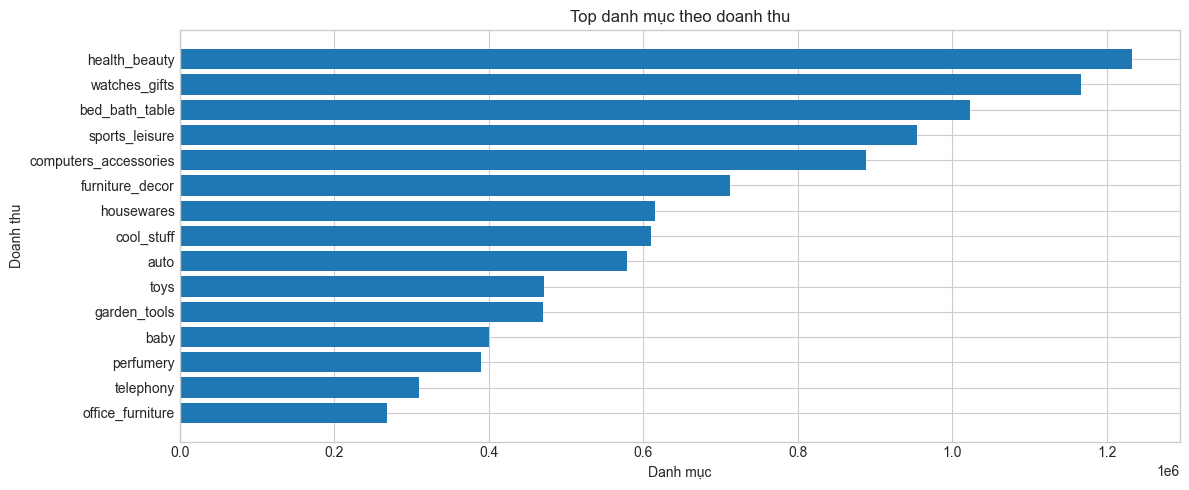

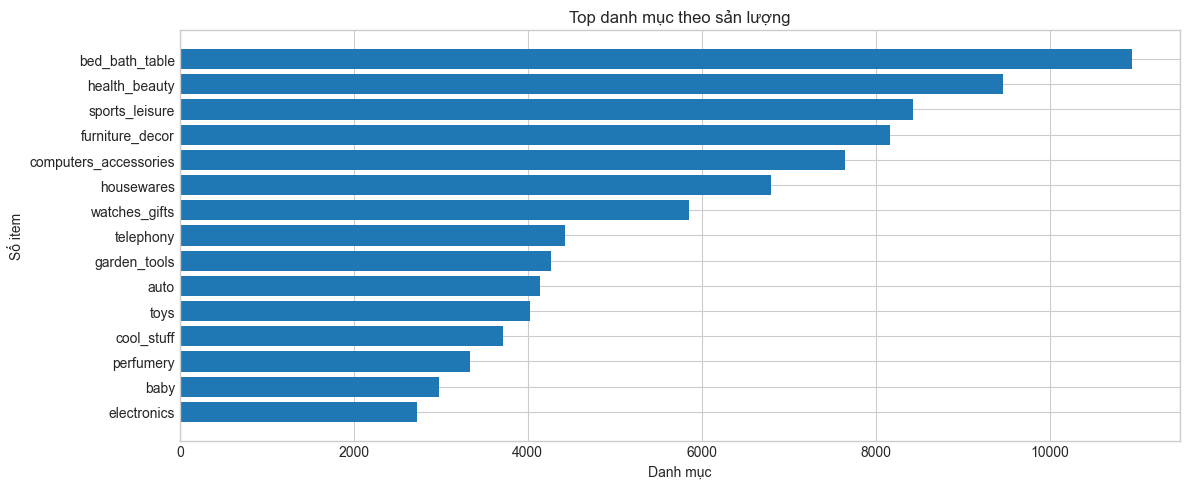

In [33]:

category_summary_df = (
    order_items_products_df
    .groupBy("product_category_name_enriched")
    .agg(
        F.count("*").alias("items_sold"),
        F.countDistinct("order_id").alias("orders_count"),
        F.sum("price").alias("gross_revenue"),
    )
    .orderBy(F.desc("gross_revenue"))
)
category_summary_df.show(20, truncate=False)
plot_bar_from_spark(category_summary_df, "product_category_name_enriched", "gross_revenue", "Top danh mục theo doanh thu", "Danh mục", "Doanh thu", 15, horizontal=True)
plot_bar_from_spark(category_summary_df.orderBy(F.desc("items_sold")), "product_category_name_enriched", "items_sold", "Top danh mục theo sản lượng", "Danh mục", "Số item", 15, horizontal=True)


[COMMAND_GIAI_THÍCH_CODE]
- Command này phân tích category sau khi đã join `order_items` với `products` và `category_translation`, đồng thời chỉ lấy delivered orders để phản ánh doanh thu đã thực hiện.
- `category_summary_df` có grain category-level và là bảng cốt lõi cho phân tích danh mục sản phẩm.
- Hai biểu đồ đi kèm giúp so sánh top category theo doanh thu và theo sản lượng.

[COMMAND_PHÂN_TÍCH_DỮ_LIỆU_VÀ_INSIGHT]
- Cách đọc output khi chạy: so sánh danh mục dẫn đầu doanh thu với danh mục dẫn đầu sản lượng để thấy sự khác biệt giữa volume-driven và value-driven.
- Insight kỳ vọng: sẽ có danh mục bán nhiều nhưng giá trị mỗi item thấp và ngược lại.
- Rủi ro dữ liệu cần chú ý: category translation thiếu map có thể đẩy category về `unknown`, cần kiểm soát ở preprocessing.

[KẾT_LUẬN_CHO_FEATURE_ENGINEERING]
- 1. Feature có thể tạo tiếp theo: category rank, avg category price, category diversity per order.
- 2. Cột rủi ro leakage hoặc chất lượng thấp: category translation thiếu mapping.
- 3. Bảng/dataset nên materialize cho bước sau: `order_items_products_df`, `category_summary_df`.


### 4.3.5. Phân tích phân bố địa lý người bán và freight


[COMMAND_SO]
Command 11

[COMMAND_MUC_DICH]
- Mục tiêu nghiệp vụ: Đánh giá seller activity, vùng bán và freight.
- Mục tiêu kỹ thuật: Aggregate seller metrics và visualize doanh thu theo bang seller.
- Command này bám mục 4.3.5.


**[C11-1] Chuẩn bị dữ liệu phân tích seller & freight**

- Join chain: `order_items` ← `orders` ← `customers` ← `sellers`.
- `same_state_flag`: so sánh `customer_state` vs `seller_state` — flag delivery nội tỉnh.
- Đây là feature quan trọng cho regression freight: giao hàng cùng bang thường rẻ hơn.


In [34]:
# Command 11 - Phân tích seller, freight và vùng bán
order_items_sellers_df = (
    order_items_typed
    .join(orders_typed.select("order_id", "customer_id"), on="order_id", how="left")
    .join(raw_tables["customers"].select("customer_id", "customer_state"), on="customer_id", how="left")
    .join(raw_tables["sellers"], on="seller_id", how="left")
    .withColumn("same_state_flag", F.when(F.col("customer_state") == F.col("seller_state"), 1).otherwise(0))
)


**[C11-2] Tổng hợp seller-level & phân tích theo bang**

- `seller_summary_df`: groupBy `(seller_id, seller_state)` → `orders_count`, `gross_revenue`,
  `avg_freight_value`, `same_state_ratio`.
- `seller_state_df`: gom lên bang-level → so sánh số seller và doanh thu theo vùng.
- **Insight kỳ vọng**: SP thống trị cả số seller lẫn doanh thu;
  `avg_freight_value` cao hơn ở các bang xa trung tâm.


+--------------------------------+------------+------------+------------------+------------------+-------------------+
|seller_id                       |seller_state|orders_count|gross_revenue     |avg_freight_value |same_state_ratio   |
+--------------------------------+------------+------------+------------------+------------------+-------------------+
|4869f7a5dfa277a7dca6462dcf3b52b2|SP          |1132        |229472.6300000004 |17.44642733564015 |0.3961937716262976 |
|53243585a1d6dc2643021fd1853d8905|BA          |358         |222776.05000000008|31.90397560975611 |0.12439024390243902|
|4a3ca9315b744ce9f8e9374361493884|SP          |1806        |200472.9200000011 |17.648233517866135|0.4489179667840966 |
|fa1c13f2614d7b5c4749cbc52fecda94|SP          |585         |194042.03000000035|17.137713310580214|0.35665529010238906|
|7c67e1448b00f6e969d365cea6b010ab|SP          |982         |187923.89000000007|37.83911290322581 |0.3951612903225806 |
|7e93a43ef30c4f03f38b393420bc753a|SP          |3

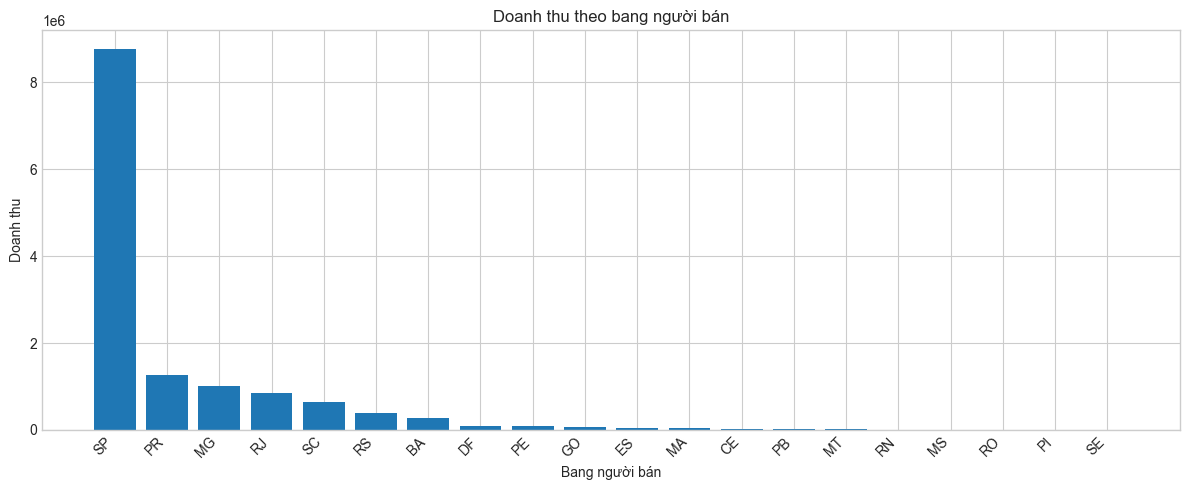

In [35]:

seller_summary_df = (
    order_items_sellers_df
    .groupBy("seller_id", "seller_state")
    .agg(
        F.countDistinct("order_id").alias("orders_count"),
        F.sum("price").alias("gross_revenue"),
        F.avg("freight_value").alias("avg_freight_value"),
        F.avg("same_state_flag").alias("same_state_ratio"),
    )
    .orderBy(F.desc("gross_revenue"))
)
seller_summary_df.show(20, truncate=False)

seller_state_df = (
    seller_summary_df
    .groupBy("seller_state")
    .agg(
        F.countDistinct("seller_id").alias("seller_count"),
        F.sum("gross_revenue").alias("gross_revenue"),
    )
    .orderBy(F.desc("gross_revenue"))
)
seller_state_df.show(20, truncate=False)
plot_bar_from_spark(seller_state_df, "seller_state", "gross_revenue", "Doanh thu theo bang người bán", "Bang người bán", "Doanh thu", 20)


[COMMAND_GIAI_THÍCH_CODE]
- `order_items_sellers_df` giữ grain order-item-level nhưng enrich customer state và seller state để phân tích freight và cùng bang/khác bang.
- `seller_summary_df` là grain seller-level; `seller_state_df` aggregate tiếp lên bang người bán.
- Biểu đồ doanh thu theo bang seller giúp nhìn nhanh mức độ tập trung vận hành.

[COMMAND_PHÂN_TÍCH_DỮ_LIỆU_VÀ_INSIGHT]
- Cách đọc output khi chạy: xem seller nào có doanh thu cao, bang nào tập trung doanh thu seller lớn và tỷ lệ cùng bang có cao hay không.
- Insight kỳ vọng: hoạt động seller thường tập trung ở một số bang lớn và có thể ảnh hưởng trực tiếp đến freight/delay.
- Rủi ro dữ liệu cần chú ý: vì bảng gốc là order-item-level, mọi metric seller phải aggregate trước khi join order-level.

[KẾT_LUẬN_CHO_FEATURE_ENGINEERING]
- 1. Feature có thể tạo tiếp theo: seller revenue rank, avg freight by seller, same_state_ratio.
- 2. Cột rủi ro leakage hoặc chất lượng thấp: freight ở grain item nếu đưa thẳng vào order-level.
- 3. Bảng/dataset nên materialize cho bước sau: `order_items_sellers_df`, `seller_summary_df`, `seller_state_df`.


### 4.3.3. Phân tích phương thức thanh toán


[COMMAND_SO]
Command 12

[COMMAND_MUC_DICH]
- Mục tiêu nghiệp vụ: Hiểu cấu trúc thanh toán và hành vi trả góp.
- Mục tiêu kỹ thuật: Aggregate payment theo payment_type và installments rồi visualize.
- Command này bám mục 4.3.3.


**[C12-1] Phân bố phương thức thanh toán**

- GroupBy `payment_type` → `payment_records`, `orders_count`, `total_payment_value`.
- **Insight kỳ vọng**: `credit_card` chiếm tỉ trọng lớn nhất; `boleto` (phiếu thanh toán Brazil)
  là phương thức phổ biến thứ 2 — đặc thù thị trường Brazil.
- Biểu đồ bar so sánh tổng giá trị thanh toán theo phương thức.


+------------+---------------+------------+-------------------+
|payment_type|payment_records|orders_count|total_payment_value|
+------------+---------------+------------+-------------------+
|credit_card |76795          |76505       |1.25420841899999E7 |
|boleto      |19784          |19784       |2869361.2699999977 |
|voucher     |5775           |3866        |379436.86999999976 |
|debit_card  |1529           |1528        |217989.78999999998 |
|not_defined |3              |3           |0.0                |
+------------+---------------+------------+-------------------+



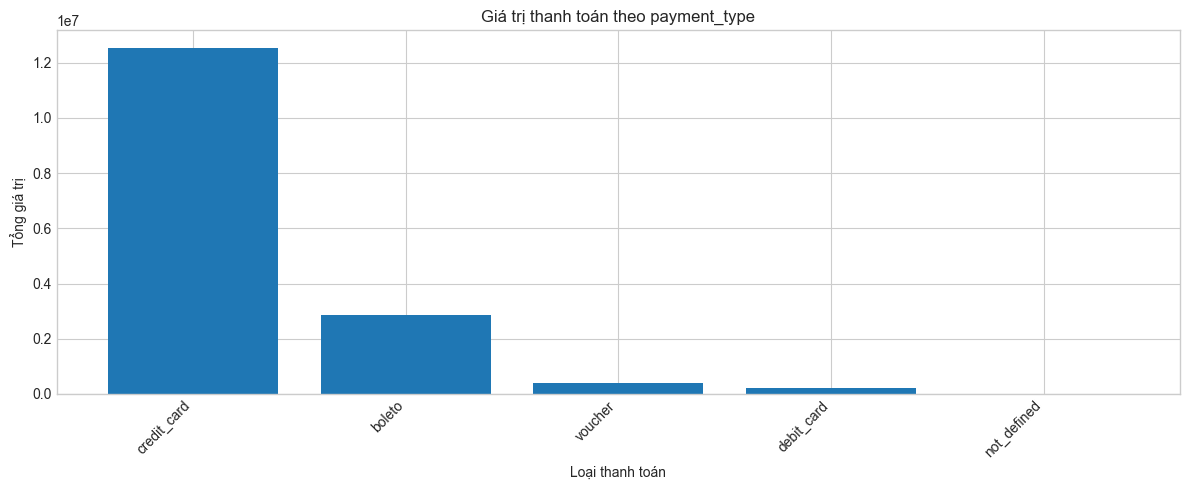

In [36]:
# Command 12 - Phân tích phương thức thanh toán
payment_type_df = (
    order_payments_typed
    .groupBy("payment_type")
    .agg(
        F.count("*").alias("payment_records"),
        F.countDistinct("order_id").alias("orders_count"),
        F.sum("payment_value").alias("total_payment_value"),
    )
    .orderBy(F.desc("total_payment_value"))
)
payment_type_df.show(truncate=False)
plot_bar_from_spark(payment_type_df, "payment_type", "total_payment_value", "Giá trị thanh toán theo payment_type", "Loại thanh toán", "Tổng giá trị", 10)


**[C12-2] Phân bố số kỳ trả góp (installments)**

- GroupBy `payment_installments` → đếm số đơn và tính `avg_payment_value`.
- **Insight kỳ vọng**: phần lớn đơn trả 1 kỳ (thanh toán một lần);
  trả góp nhiều kỳ thường đi kèm giá trị đơn hàng cao hơn.
- Feature `max_payment_installments` trong FE pipeline được xây từ insight này.


+--------------------+------------+------------------+
|payment_installments|orders_count|avg_payment_value |
+--------------------+------------+------------------+
|0                   |2           |94.315            |
|1                   |49060       |112.42022913256994|
|2                   |12389       |127.22815032627084|
|3                   |10443       |142.5393174648699 |
|4                   |7088        |163.97683995491687|
|5                   |5234        |183.46522237068137|
|6                   |3916        |209.84995153061223|
|7                   |1623        |187.67367158671587|
|8                   |4253        |307.7374273664481 |
|9                   |644         |203.44086956521747|
|10                  |5315        |415.08583708708704|
|11                  |23          |124.9321739130435 |
|12                  |133         |321.6784962406015 |
|13                  |16          |150.46249999999998|
|14                  |15          |167.96266666666668|
|15       

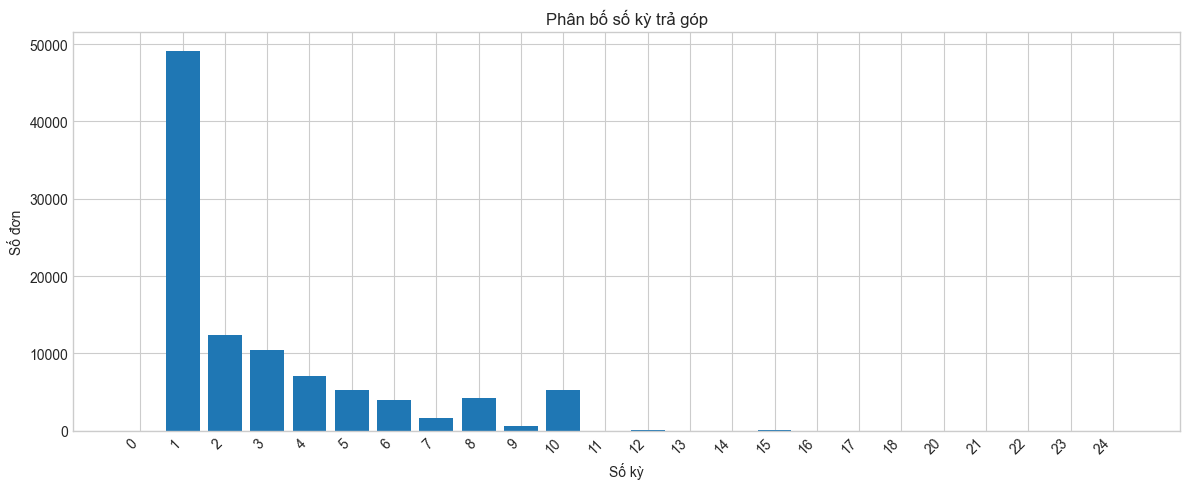

In [37]:

installments_df = (
    order_payments_typed
    .groupBy("payment_installments")
    .agg(
        F.countDistinct("order_id").alias("orders_count"),
        F.avg("payment_value").alias("avg_payment_value"),
    )
    .orderBy("payment_installments")
)
installments_df.show(30, truncate=False)
plot_bar_from_spark(installments_df, "payment_installments", "orders_count", "Phân bố số kỳ trả góp", "Số kỳ", "Số đơn", 30)


[COMMAND_GIAI_THÍCH_CODE]
- Command này phân tích dữ liệu thanh toán trực tiếp từ file `order_payments`, chưa join rộng sang các bảng khác.
- `payment_type_df` có grain payment_type-level; `installments_df` có grain số kỳ trả góp.
- Hai biểu đồ giúp đọc nhanh cấu trúc thanh toán trên sàn.

[COMMAND_PHÂN_TÍCH_DỮ_LIỆU_VÀ_INSIGHT]
- Cách đọc output khi chạy: xem payment type nào chiếm giá trị lớn nhất và installment nào phổ biến nhất.
- Insight kỳ vọng: installment là tín hiệu hành vi tài chính hữu ích; một số payment type có thể gắn với mức chi tiêu khác nhau.
- Rủi ro dữ liệu cần chú ý: `order_payments` là grain payment-line, không được join thẳng vào orders nếu đích là order-level.

[KẾT_LUẬN_CHO_FEATURE_ENGINEERING]
- 1. Feature có thể tạo tiếp theo: payment_total_value, max_installments, multi_payment_flag.
- 2. Cột rủi ro leakage hoặc chất lượng thấp: chưa phải leakage trực tiếp, nhưng grain sai sẽ gây méo feature.
- 3. Bảng/dataset nên materialize cho bước sau: `payment_type_df`, `installments_df`.


### 4.3.2. Phân bố điểm đánh giá review_score
### 4.3.6. Phân tích review text và độ dài bình luận


[COMMAND_SO]
Command 13

[COMMAND_MUC_DICH]
- Mục tiêu nghiệp vụ: Hiểu phân bố score và mức độ sẵn sàng của review text.
- Mục tiêu kỹ thuật: Tạo review text readiness, aggregate score và độ dài comment rồi visualize.
- Command này bám mục 4.3.2 và 4.3.6.


**[C13-1] Chuẩn bị & phân tích phân bố review_score**

- `reviews_text_ready_df`: chuẩn hóa text comment (lowercase + trim + collapse whitespace).
- `has_review_comment`: flag `1` nếu comment có nội dung (length > 0).
- `comment_length`: độ dài text sau clean.
- `review_score_df`: phân bố điểm đánh giá 1-5 + biểu đồ bar.
- **Insight kỳ vọng**: review score 5 chiếm nhiều nhất (skew về phía dương);
  đây là lý do dùng `is_low_review` (score ≤ 3) làm binary classification target.


+------------+------------+
|review_score|review_count|
+------------+------------+
|NULL        |4935        |
|0           |2           |
|1           |11424       |
|2           |3151        |
|3           |8179        |
|4           |19142       |
|5           |57328       |
|90          |1           |
+------------+------------+



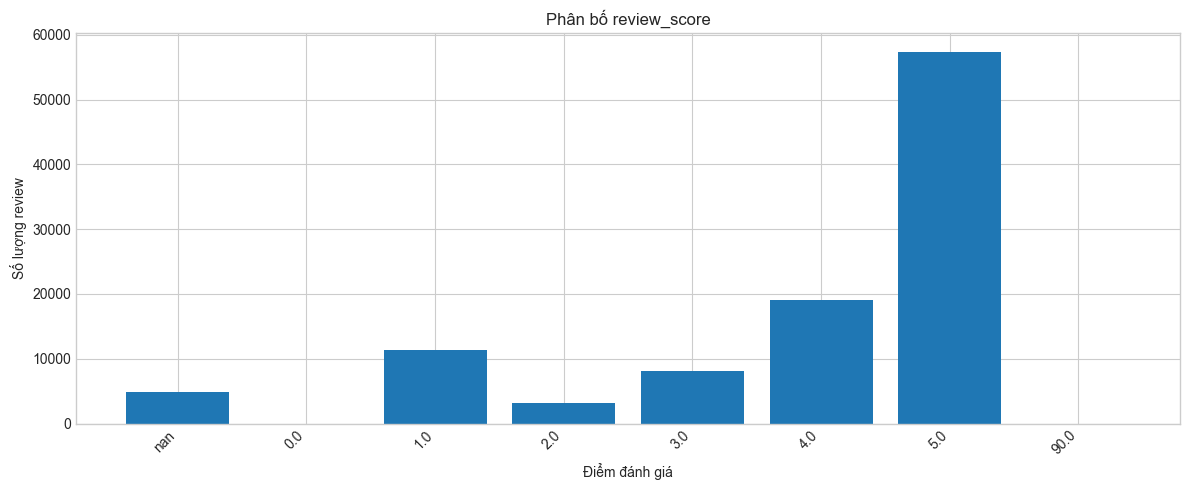

In [38]:
# Command 13 - Phân bố review_score, review text và độ dài bình luận
reviews_text_ready_df = (
    order_reviews_typed
    .withColumn("review_comment_message_clean", F.lower(F.trim(F.regexp_replace(F.coalesce(F.col("review_comment_message"), F.lit("")), r"\s+", " "))))
    .withColumn("has_review_comment", F.when(F.length(F.col("review_comment_message_clean")) > 0, 1).otherwise(0))
    .withColumn("comment_length", F.length(F.col("review_comment_message_clean")))
)

review_score_df = (
    reviews_text_ready_df
    .groupBy("review_score")
    .agg(F.count("*").alias("review_count"))
    .orderBy("review_score")
)
review_score_df.show(truncate=False)
plot_bar_from_spark(review_score_df, "review_score", "review_count", "Phân bố review_score", "Điểm đánh giá", "Số lượng review", 10)


**[C13-2] Phân tích coverage text review & phân phối độ dài comment**

- `review_text_coverage_df`: tỉ lệ review có comment, avg length, median length.
- `comment_length_bucket_df`: phân nhóm theo độ dài (0, 1-50, 51-100, >100 ký tự).
- **Insight kỳ vọng**: tỉ lệ có comment thấp (~40%) — text feature có thể hữu ích nhưng cần
  fill rỗng để tránh mất dữ liệu khi không có comment.
- Insight này giải thích tại sao FE pipeline dùng `coalesce(review_text, '')` và có `has_review_comment` flag.


+-------------+--------------------+------------------+---------------------+
|total_reviews|reviews_with_comment|avg_comment_length|median_comment_length|
+-------------+--------------------+------------------+---------------------+
|104162       |41073               |25.376548069353507|0                    |
+-------------+--------------------+------------------+---------------------+

+---------------------+------------+
|comment_length_bucket|review_count|
+---------------------+------------+
|0                    |63089       |
|1-50                 |20971       |
|51-100               |11882       |
|>100                 |8220        |
+---------------------+------------+



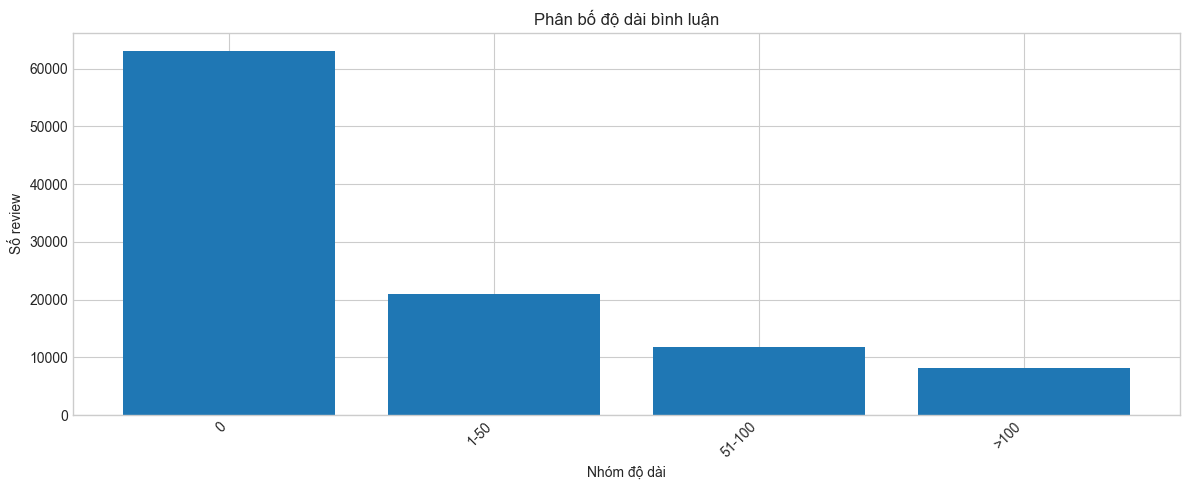

In [39]:

review_text_coverage_df = reviews_text_ready_df.select(
    F.count("*").alias("total_reviews"),
    F.sum("has_review_comment").alias("reviews_with_comment"),
    F.avg("comment_length").alias("avg_comment_length"),
    F.expr("percentile_approx(comment_length, 0.5)").alias("median_comment_length"),
)
review_text_coverage_df.show(truncate=False)

comment_length_bucket_df = (
    reviews_text_ready_df
    .withColumn(
        "comment_length_bucket",
        F.when(F.col("comment_length") == 0, "0")
        .when(F.col("comment_length").between(1, 50), "1-50")
        .when(F.col("comment_length").between(51, 100), "51-100")
        .otherwise(">100"),
    )
    .groupBy("comment_length_bucket")
    .agg(F.count("*").alias("review_count"))
    .orderBy("comment_length_bucket")
)
comment_length_bucket_df.show(truncate=False)
plot_bar_from_spark(comment_length_bucket_df, "comment_length_bucket", "review_count", "Phân bố độ dài bình luận", "Nhóm độ dài", "Số review", 10)


[COMMAND_GIAI_THÍCH_CODE]
- Command này tách riêng phần review thành hai hướng: phân phối `review_score` và mức độ sẵn sàng của review text.
- `reviews_text_ready_df` vẫn ở grain review-level; các bảng summary phía sau đã aggregate nhỏ để phục vụ visualize.
- Text cleaning ở đây chỉ ở mức tối thiểu vì mục tiêu là readiness, chưa sang modeling NLP.

[COMMAND_PHÂN_TÍCH_DỮ_LIỆU_VÀ_INSIGHT]
- Cách đọc output khi chạy: xem score nào áp đảo, tỷ lệ review có comment thực sự là bao nhiêu và bình luận thường dài ngắn ra sao.
- Insight kỳ vọng: `review_score` thường mất cân bằng và review text có tỷ lệ null/empty cao.
- Rủi ro dữ liệu cần chú ý: nếu target là `review_score`, mọi feature tạo từ review text đều là leakage.

[KẾT_LUẬN_CHO_FEATURE_ENGINEERING]
- 1. Feature có thể tạo tiếp theo: has_review_comment, comment_length, TF-IDF/Word2Vec readiness.
- 2. Cột rủi ro leakage hoặc chất lượng thấp: `review_comment_message`, `review_score` cho bài toán dự báo sớm.
- 3. Bảng/dataset nên materialize cho bước sau: `reviews_text_ready_df`, `review_score_df`, `comment_length_bucket_df`.


### 4.3.1. Góc nhìn logistics theo thời gian
### 4.3.7. Insight về SLA và giao hàng


[COMMAND_SO]
Command 14

[COMMAND_MUC_DICH]
- Mục tiêu nghiệp vụ: Đánh giá tốc độ giao hàng và độ trễ.
- Mục tiêu kỹ thuật: Tạo delay buckets và visualize phân bố delay.
- Command này bám mục 4.3.1 và 4.3.7.


**[C14-1] Tính toán các chỉ số logistics**

- `delivery_days = (delivered_customer_date - purchase_timestamp) / 86400`: thời gian giao hàng thực tế (ngày).
- `estimated_days = (estimated_delivery_date - purchase_timestamp) / 86400`: thời gian dự kiến.
- `delay_days = delivered_customer_date - estimated_delivery_date`: delay dương = trễ, âm = sớm.
- `delay_bucket`: phân nhóm delay thành 4 mức (`on_time_or_early`, `late_1_3`, `late_4_7`, `late_over_7`).
- Tính `median_delivery_days`, `median_estimated_days`, `median_delay_days` để có baseline SLA.


In [40]:
# Command 14 - Logistics: delivery time, estimated time, delay
logistics_df = (
    orders_typed
    .filter(F.col("order_purchase_timestamp").isNotNull())
    .withColumn("delivery_days", (F.unix_timestamp("order_delivered_customer_date") - F.unix_timestamp("order_purchase_timestamp")) / 86400)
    .withColumn("estimated_days", (F.unix_timestamp("order_estimated_delivery_date") - F.unix_timestamp("order_purchase_timestamp")) / 86400)
    .withColumn("delay_days", (F.unix_timestamp("order_delivered_customer_date") - F.unix_timestamp("order_estimated_delivery_date")) / 86400)
    .withColumn(
        "delay_bucket",
        F.when(F.col("delay_days").isNull(), "missing")
        .when(F.col("delay_days") <= 0, "on_time_or_early")
        .when(F.col("delay_days") <= 3, "late_1_3_days")
        .when(F.col("delay_days") <= 7, "late_4_7_days")
        .otherwise("late_over_7_days"),
    )
)

logistics_summary_df = logistics_df.select(
    F.expr("percentile_approx(delivery_days, 0.5)").alias("median_delivery_days"),
    F.expr("percentile_approx(estimated_days, 0.5)").alias("median_estimated_days"),
    F.expr("percentile_approx(delay_days, 0.5)").alias("median_delay_days"),
)
logistics_summary_df.show(truncate=False)


+--------------------+---------------------+-------------------+
|median_delivery_days|median_estimated_days|median_delay_days  |
+--------------------+---------------------+-------------------+
|10.21630787037037   |23.239305555555557   |-11.950023148148148|
+--------------------+---------------------+-------------------+



**[C14-2] Phân bố độ trễ giao hàng (delay buckets)**

- `delay_bucket_df`: groupBy `delay_bucket` đếm số đơn trong mỗi nhóm.
- Biểu đồ bar trực quan hóa tỉ lệ đơn đúng hạn vs trễ.
- **Insight kỳ vọng**: phần lớn đơn giao đúng hạn hoặc sớm;
  delay là **high leakage feature** (biến outcome) — không được dùng làm input cho dự báo sớm.
- Insight này trực tiếp giải thích thiết kế leakage_reference_df ở Command 7.


+----------------+-----------+
|delay_bucket    |order_count|
+----------------+-----------+
|on_time_or_early|88649      |
|late_over_7_days|3346       |
|missing         |2965       |
|late_1_3_days   |2662       |
|late_4_7_days   |1819       |
+----------------+-----------+



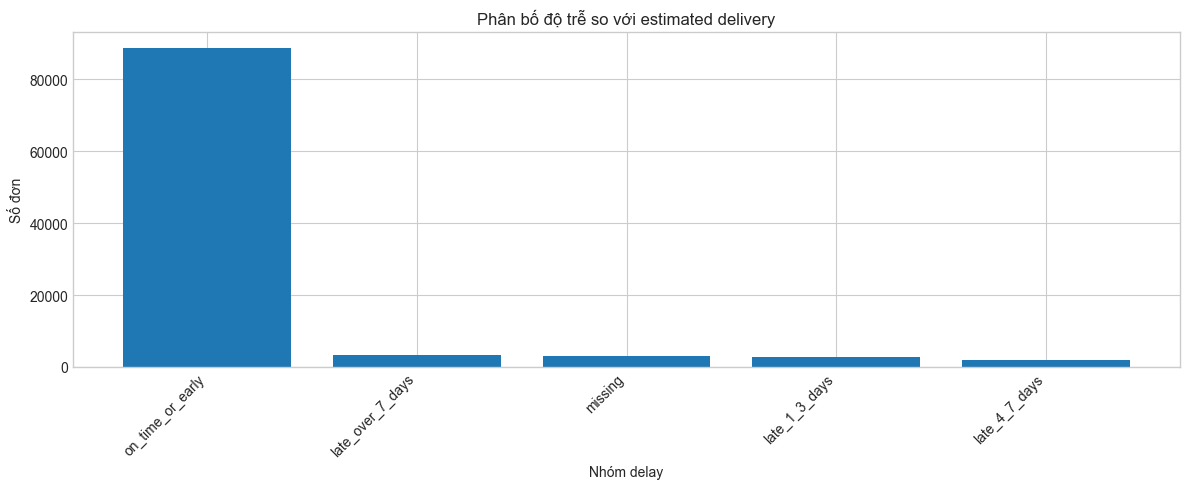

In [41]:

delay_bucket_df = (
    logistics_df
    .groupBy("delay_bucket")
    .agg(F.countDistinct("order_id").alias("order_count"))
    .orderBy(F.desc("order_count"))
)
delay_bucket_df.show(truncate=False)
plot_bar_from_spark(delay_bucket_df, "delay_bucket", "order_count", "Phân bố độ trễ so với estimated delivery", "Nhóm delay", "Số đơn", 10)


[COMMAND_GIAI_THÍCH_CODE]
- `logistics_df` giữ grain order-level và tạo ba biến trọng tâm: `delivery_days`, `estimated_days`, `delay_days`.
- `delay_bucket_df` biến delay thành nhóm dễ đọc cho EDA và cũng là ứng viên tốt cho categorical feature.
- Visual ở đây phục vụ cả EDA nghiệp vụ lẫn chuẩn bị feature logistics.

[COMMAND_PHÂN_TÍCH_DỮ_LIỆU_VÀ_INSIGHT]
- Cách đọc output khi chạy: so sánh estimated với actual delivery, xem nhóm trễ nào chiếm tỷ trọng lớn.
- Insight kỳ vọng: đa số đơn có thể on-time hoặc trễ nhẹ, còn tail trễ dài ngày là nhóm cần chú ý.
- Rủi ro dữ liệu cần chú ý: `delay_days` là outcome hậu vận hành, không dùng cho dự báo sớm tại thời điểm mua.

[KẾT_LUẬN_CHO_FEATURE_ENGINEERING]
- 1. Feature có thể tạo tiếp theo: on_time_flag, delay_bucket, delivery_lag.
- 2. Cột rủi ro leakage hoặc chất lượng thấp: toàn bộ cột delivery outcome cho early prediction.
- 3. Bảng/dataset nên materialize cho bước sau: `logistics_df`, `delay_bucket_df`, `logistics_summary_df`.


### 4.3.5. Phân tích phân bố địa lý khách hàng và người bán


[COMMAND_SO]
Command 15

[COMMAND_MUC_DICH]
- Mục tiêu nghiệp vụ: So sánh phân bố state của khách hàng và người bán.
- Mục tiêu kỹ thuật: Aggregate theo state và visualize top states.
- Command này bám mục 4.3.5.


**[C15-1] Phân bố địa lý customer và seller theo bang**

- `customer_state_df`: unique customer theo bang → bar chart top 20 bang.
- `seller_state_df`: unique seller theo bang → bar chart top 20 bang.
- **Insight kỳ vọng**: SP (São Paulo) dẫn đầu cả customer lẫn seller;
  vùng Đông Nam Brazil (SP, RJ, MG) chiếm đa số — thị trường tập trung.


+--------------+----------------+
|customer_state|unique_customers|
+--------------+----------------+
|SP            |40302           |
|RJ            |12384           |
|MG            |11259           |
|RS            |5277            |
|PR            |4882            |
|SC            |3534            |
|BA            |3277            |
|DF            |2075            |
|ES            |1964            |
|GO            |1952            |
|PE            |1609            |
|CE            |1313            |
|PA            |949             |
|MT            |876             |
|MA            |726             |
|MS            |694             |
|PB            |519             |
|PI            |482             |
|RN            |474             |
|AL            |401             |
+--------------+----------------+
only showing top 20 rows



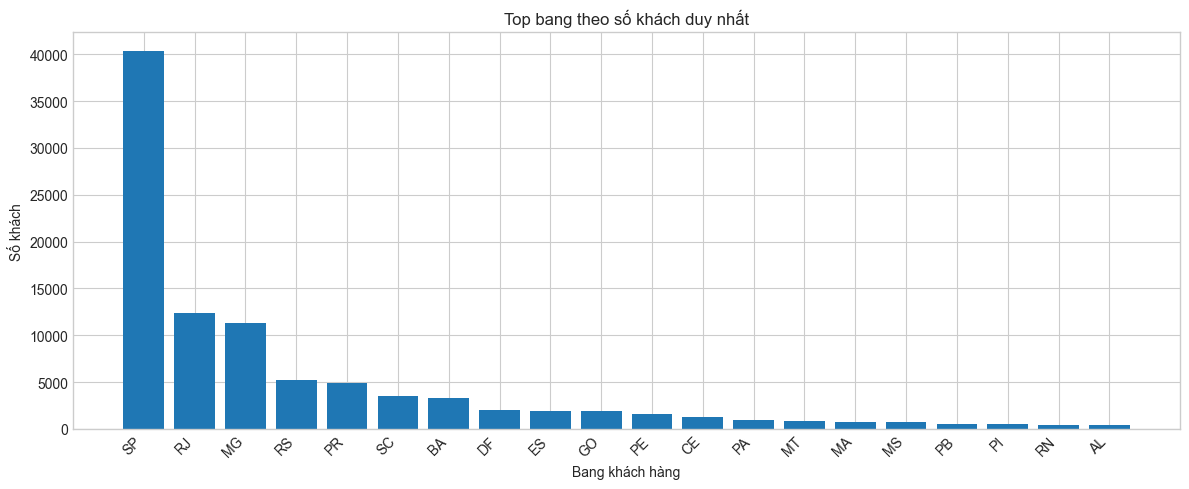

+------------+------------+
|seller_state|seller_count|
+------------+------------+
|SP          |1849        |
|PR          |349         |
|MG          |244         |
|SC          |190         |
|RJ          |171         |
|RS          |129         |
|GO          |40          |
|DF          |30          |
|ES          |23          |
|BA          |19          |
|CE          |13          |
|PE          |9           |
|PB          |6           |
|MS          |5           |
|RN          |5           |
|MT          |4           |
|RO          |2           |
|SE          |2           |
|AC          |1           |
|PI          |1           |
+------------+------------+
only showing top 20 rows



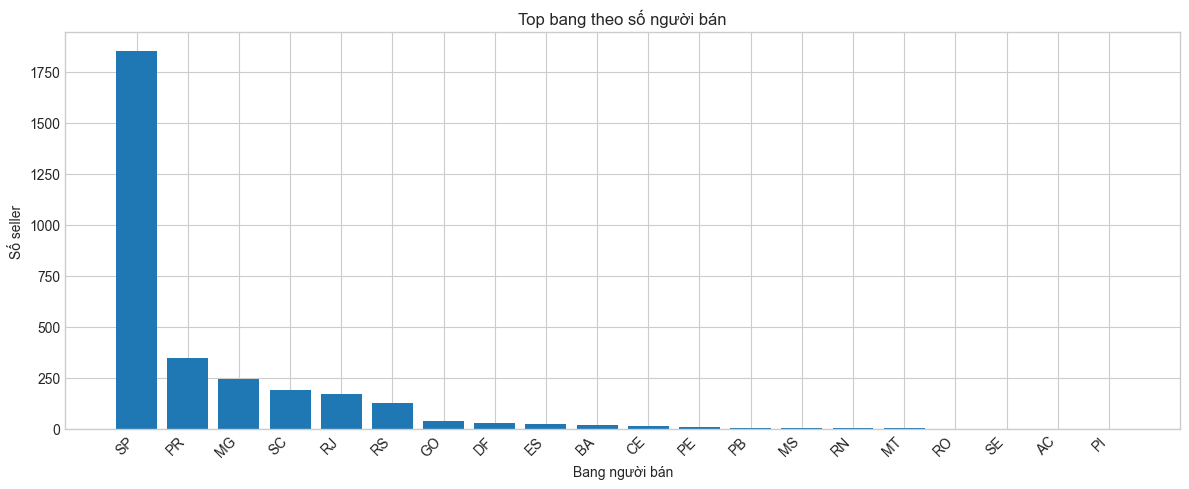

In [42]:
# Command 15 - Phân bố địa lý khách hàng và người bán
customer_state_df = (
    raw_tables["customers"]
    .groupBy("customer_state")
    .agg(F.countDistinct("customer_unique_id").alias("unique_customers"))
    .orderBy(F.desc("unique_customers"))
)
customer_state_df.show(20, truncate=False)
plot_bar_from_spark(customer_state_df, "customer_state", "unique_customers", "Top bang theo số khách duy nhất", "Bang khách hàng", "Số khách", 20)

seller_state_df = (
    raw_tables["sellers"]
    .groupBy("seller_state")
    .agg(F.countDistinct("seller_id").alias("seller_count"))
    .orderBy(F.desc("seller_count"))
)
seller_state_df.show(20, truncate=False)
plot_bar_from_spark(seller_state_df, "seller_state", "seller_count", "Top bang theo số người bán", "Bang người bán", "Số seller", 20)


**[C15-2] Cross-state order flow (customer → seller)**

- Join chain: `orders` ← `customers(state)` ← `order_items(seller_id)` ← `sellers(state)`.
- GroupBy `(customer_state, seller_state)` → `order_count`.
- **Insight kỳ vọng**: hầu hết đơn hàng đặt từ SP và được ship từ SP;
  luồng cross-state nhiều → `same_state_any_seller_flag` là feature địa lý hữu ích.


In [43]:

customer_seller_flow_df = (
    orders_typed
    .join(raw_tables["customers"].select("customer_id", "customer_state"), on="customer_id", how="left")
    .join(order_items_typed.select("order_id", "seller_id").dropDuplicates(), on="order_id", how="left")
    .join(raw_tables["sellers"].select("seller_id", "seller_state"), on="seller_id", how="left")
    .groupBy("customer_state", "seller_state")
    .agg(F.countDistinct("order_id").alias("order_count"))
    .orderBy(F.desc("order_count"))
)
customer_seller_flow_df.show(20, truncate=False)


+--------------+------------+-----------+
|customer_state|seller_state|order_count|
+--------------+------------+-----------+
|SP            |SP          |31502      |
|RJ            |SP          |8457       |
|MG            |SP          |7591       |
|RS            |SP          |3668       |
|PR            |SP          |3177       |
|SP            |PR          |3019       |
|SP            |MG          |2633       |
|BA            |SP          |2387       |
|SC            |SP          |2370       |
|MG            |MG          |1572       |
|ES            |SP          |1492       |
|GO            |SP          |1463       |
|DF            |SP          |1415       |
|SP            |RJ          |1381       |
|SP            |SC          |1348       |
|RJ            |MG          |1196       |
|PE            |SP          |1172       |
|CE            |SP          |1009       |
|RJ            |PR          |1007       |
|RJ            |RJ          |998        |
+--------------+------------+-----

[COMMAND_GIAI_THÍCH_CODE]
- Command này phân tích địa lý ở mức state trước vì đây là mức ổn định hơn city và an toàn hơn geolocation raw.
- `customer_seller_flow_df` mô tả luồng đơn hàng giữa bang khách và bang seller, hữu ích cho freight và logistics analysis.
- Visual chỉ dùng cho aggregate nhỏ ở cấp state để tránh nổ dữ liệu.

[COMMAND_PHÂN_TÍCH_DỮ_LIỆU_VÀ_INSIGHT]
- Cách đọc output khi chạy: xem bang nào tập trung nhiều khách nhất, bang nào nhiều seller nhất và cặp bang nào phát sinh nhiều order.
- Insight kỳ vọng: phân bố địa lý sẽ tập trung vào vài bang lớn, tạo tiền đề cho geo features và same-state features.
- Rủi ro dữ liệu cần chú ý: city raw có thể nhiễu do chuẩn hóa tên chưa triệt để; state ổn định hơn cho EDA đầu tiên.

[KẾT_LUẬN_CHO_FEATURE_ENGINEERING]
- 1. Feature có thể tạo tiếp theo: customer_state, seller_state, same_state_flag, state-pair density.
- 2. Cột rủi ro leakage hoặc chất lượng thấp: city raw nếu chưa normalize kỹ.
- 3. Bảng/dataset nên materialize cho bước sau: `customer_state_df`, `seller_state_df`, `customer_seller_flow_df`.


### 4.3.7. Các insight chính rút ra từ EDA


[COMMAND_SO]
Command 16

[COMMAND_MUC_DICH]
- Mục tiêu nghiệp vụ: Tổng hợp basket, GMV và chốt insight chính từ EDA.
- Mục tiêu kỹ thuật: Tạo order-level basket summary và visualize basket distribution.
- Command này bám mục 4.3.7.


**[C16-1] Phân tích giỏ hàng (basket) và order GMV**

- `order_basket_summary_df`: groupBy `order_id`, tổng hợp `items_per_order`, `unique_products`,
  `unique_categories`, `order_item_value`, `order_freight_value`, `order_gmv = item + freight`.
- `basket_bucket_df`: phân nhóm theo số item (`1`, `2-3`, `4-5`, `≥6`) + bar chart.
- `order_value_summary_df`: `median_order_gmv`, `P90_order_gmv`, `median_items_per_order`.
- **Insight kỳ vọng**: phần lớn đơn chỉ có 1 item;
  đây là nền tảng cho FP-Growth (basket ≥ 2 items) và regression target (`order_gmv`).


+--------------------------------+---------------+-------------------------+---------------------------+----------------+-------------------+------------------+
|order_id                        |items_per_order|unique_products_per_order|unique_categories_per_order|order_item_value|order_freight_value|order_gmv         |
+--------------------------------+---------------+-------------------------+---------------------------+----------------+-------------------+------------------+
|000f25f4d72195062c040b12dce9a18a|1              |1                        |1                          |119.99          |44.4               |164.39            |
|0011d82c4b53e22e84023405fb467e57|1              |1                        |1                          |289.0           |26.33              |315.33            |
|00130c0eee84a3d909e75bc08c5c3ca1|1              |1                        |1                          |27.9            |7.94               |35.839999999999996|
|004345d16a1ab2c21962992c721c8643|

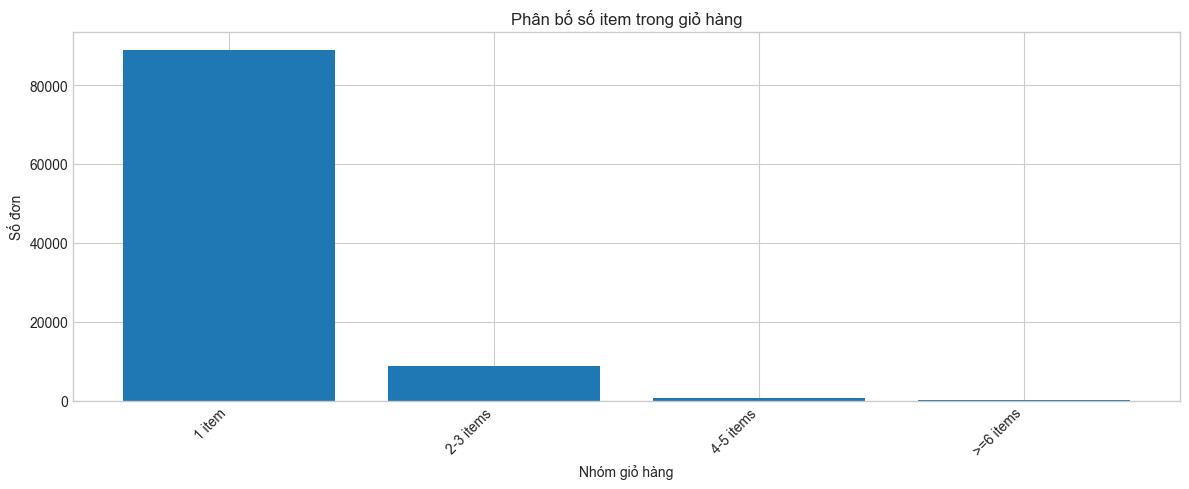

+----------------+-------------+----------------------+
|median_order_gmv|p90_order_gmv|median_items_per_order|
+----------------+-------------+----------------------+
|105.28          |307.5        |1                     |
+----------------+-------------+----------------------+



In [44]:
# Command 16 - Basket, order value và tổng hợp insight chính từ EDA
order_basket_summary_df = (
    order_items_typed
    .join(raw_tables["products"].select("product_id", "product_category_name"), on="product_id", how="left")
    .groupBy("order_id")
    .agg(
        F.count("*").alias("items_per_order"),
        F.countDistinct("product_id").alias("unique_products_per_order"),
        F.countDistinct("product_category_name").alias("unique_categories_per_order"),
        F.sum("price").alias("order_item_value"),
        F.sum("freight_value").alias("order_freight_value"),
    )
    .withColumn("order_gmv", F.col("order_item_value") + F.col("order_freight_value"))
)
order_basket_summary_df.show(10, truncate=False)

basket_bucket_df = (
    order_basket_summary_df
    .withColumn(
        "basket_bucket",
        F.when(F.col("items_per_order") == 1, "1 item")
        .when(F.col("items_per_order").between(2, 3), "2-3 items")
        .when(F.col("items_per_order").between(4, 5), "4-5 items")
        .otherwise(">=6 items"),
    )
    .groupBy("basket_bucket")
    .agg(F.countDistinct("order_id").alias("order_count"))
    .orderBy(F.desc("order_count"))
)
basket_bucket_df.show(truncate=False)
plot_bar_from_spark(basket_bucket_df, "basket_bucket", "order_count", "Phân bố số item trong giỏ hàng", "Nhóm giỏ hàng", "Số đơn", 10)

order_value_summary_df = order_basket_summary_df.select(
    F.expr("percentile_approx(order_gmv, 0.5)").alias("median_order_gmv"),
    F.expr("percentile_approx(order_gmv, 0.9)").alias("p90_order_gmv"),
    F.expr("percentile_approx(items_per_order, 0.5)").alias("median_items_per_order"),
)
order_value_summary_df.show(truncate=False)


**[C16-2] Tổng hợp insight chính từ toàn bộ EDA**

- `eda_insight_df`: bảng tóm tắt 6 insight chính theo domain (Orders, Customers, Payments, Reviews, Logistics, Basket).
- Đây là **bảng kết luận** của notebook 01 — mỗi insight ánh xạ trực tiếp đến một quyết định
  thiết kế trong notebook 02 (preprocessing) và 03 (feature engineering).
- In bảng này làm checkpoint cuối trước khi chuyển sang pha xử lý dữ liệu.


In [45]:

eda_insight_df = create_spark_df_from_rows(
    [
        ("Orders", "Xu hướng đơn hàng theo thời gian hỗ trợ tạo seasonal features"),
        ("Customers", "Phải dùng customer_unique_id cho history và RFM"),
        ("Payments", "Cần aggregate payment về order-level trước khi join"),
        ("Reviews", "Review text hữu ích cho NLP nhưng dễ leakage"),
        ("Logistics", "Delay là biến outcome mạnh nhưng không an toàn cho early prediction"),
        ("Basket", "Order_gmv và basket size là base tốt cho regression và FP-Growth"),
    ],
    ["eda_domain", "key_takeaway"],
)
eda_insight_df.show(truncate=False)


+----------+-------------------------------------------------------------------+
|eda_domain|key_takeaway                                                       |
+----------+-------------------------------------------------------------------+
|Orders    |Xu hướng đơn hàng theo thời gian hỗ trợ tạo seasonal features      |
|Customers |Phải dùng customer_unique_id cho history và RFM                    |
|Payments  |Cần aggregate payment về order-level trước khi join                |
|Reviews   |Review text hữu ích cho NLP nhưng dễ leakage                       |
|Logistics |Delay là biến outcome mạnh nhưng không an toàn cho early prediction|
|Basket    |Order_gmv và basket size là base tốt cho regression và FP-Growth   |
+----------+-------------------------------------------------------------------+



[COMMAND_GIAI_THÍCH_CODE]
- Command cuối của notebook 01 gom lại góc nhìn basket và order value để kết nối EDA với preprocessing/modeling.
- `order_basket_summary_df` có grain order-level và là một trong những bảng trung gian quan trọng nhất cho `master_orders` sau này.
- `eda_insight_df` không bịa số liệu mà đóng vai trò checklist insight theo domain.

[COMMAND_PHÂN_TÍCH_DỮ_LIỆU_VÀ_INSIGHT]
- Cách đọc output khi chạy: xem đơn hàng thường có bao nhiêu item, GMV trung vị ra sao và basket size phân bố thế nào.
- Insight kỳ vọng: phần lớn giỏ hàng sẽ nhỏ, nhưng một nhóm ít đơn có GMV cao sẽ tạo tail đáng chú ý cho regression và segmentation.
- Rủi ro dữ liệu cần chú ý: `order_gmv` ở đây là giá trị tính từ item + freight, cần đối chiếu với payment aggregate ở notebook preprocessing.

[KẾT_LUẬN_CHO_FEATURE_ENGINEERING]
- 1. Feature có thể tạo tiếp theo: order_gmv_log, basket_bucket, unique_categories_per_order.
- 2. Cột rủi ro leakage hoặc chất lượng thấp: các biến hậu vận hành khi dùng cho bài toán dự báo sớm.
- 3. Bảng/dataset nên materialize cho bước sau: `order_basket_summary_df`, `basket_bucket_df`, `order_value_summary_df`.
